---
title: "Gradient Optimization: SGD to Adam"
short_title: "Gradient Optimization"
subject: DEEP LEARNING
---

## Introduction

Recall that we can visualize $\mathcal{L}_{\mathcal{D}}(\boldsymbol{\Theta})$ as a surface ({numref}`02-loss-surface`). Recall that **Gradient Descent** (GD) finds the minimum by locally moving in the direction of greatest decrease in loss ({numref}`02-gradient-descent-1d`). The step-size in GD depends on (1) the **learning rate**, and (2) the magnitude of the gradient. It turns out that learning rate has to be tuned well: a too large learning rate can result in overshooting the minimum and causing oscillations, while a too small learning rate can lead to slow convergence or getting stuck in local minima or plateaus. 

In this notebook, we will discuss variants of gradient descent to deal with this issue including **momentum** and adaptive momentum techniques, such as **RMSProp** {cite:p}`rmsprop` and  **Adam** {cite:p}`adam`, which adjust the learning rate during training and dampen oscillations to improve optimization performance. Finally, we look at **Stochastic Gradient Descent** (SGD) which is critical for applications of GD in data-driven problems.

:::::{grid} 2

::::{card}
:::{figure} ./img/02-loss-surface.png
---
name: 02-loss-surface
width: 100%
align: center
---
Loss surface 2-param model. [**Source**](https://cs182sp21.github.io/static/slides/lec-4.pdf)
:::
::::

::::{card}
:::{figure} ./img/02-gradient-descent-1d.png
---
name: 02-gradient-descent-1d
width: 100%
align: center
---
**Gradient descent in 1-dim.** 
GD update uses the negative of the gradient, i.e. opposite to the direction of the slope. 
Moreover, step-size in vanilla GD is effectively scaled by the magnitude of the gradient. [**Source**](https://cs182sp21.github.io/static/slides/lec-4.pdf)
:::
::::

:::::

In [1]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import torch
import torch.nn as nn
import random
import numpy as np
import pandas as pd

RANDOM_SEED = 0
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

def get_device(): 
    return (
        torch.device("cuda:0") if torch.cuda.is_available() else (
            torch.device("mps") if torch.mps.is_available() else 
                torch.device("cpu")
        )
    )

DEVICE = get_device()
print(f"Using device: {DEVICE}")

Using device: mps


### Optimizer template

To experiment with GD algorithms, we create a template class. The template implements a method for zeroing out the gradients. 
The only method that typically needs to be changed is `update_param` which contains the algorithm for updating parameters.

In [2]:
class OptimizerBase:
    def __init__(self, params: list, lr: float):
        self.params = params
        self.lr = lr

    def zero_grad(self):
        for p in self.params:
            if p.grad is None:
                continue
            p.grad.detach_()
            p.grad.zero_()

    @torch.no_grad()
    def step(self):
        for p in self.params:
            if p.grad is None:
                continue
            self.update_param(p)

    def update_param(self, p):
        raise NotImplementedError

Gradient descent can be implemented with the template as follows:

In [3]:
class GD(OptimizerBase):
    def __init__(self, params, lr):
        super().__init__(params, lr)

    def update_param(self, p):
        p += -self.lr * p.grad

### Pathological loss

We will test with the following [synthetic loss surface](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial4/Optimization_and_Initialization.html
) (i.e. not generated with data):

In [4]:
#| label: pathological_loss
def pathological_loss(w0, w1):
    l1 = torch.tanh(w0) ** 2 + 0.01 * torch.abs(w1)
    l2 = torch.sigmoid(w1)
    return l1 + l2

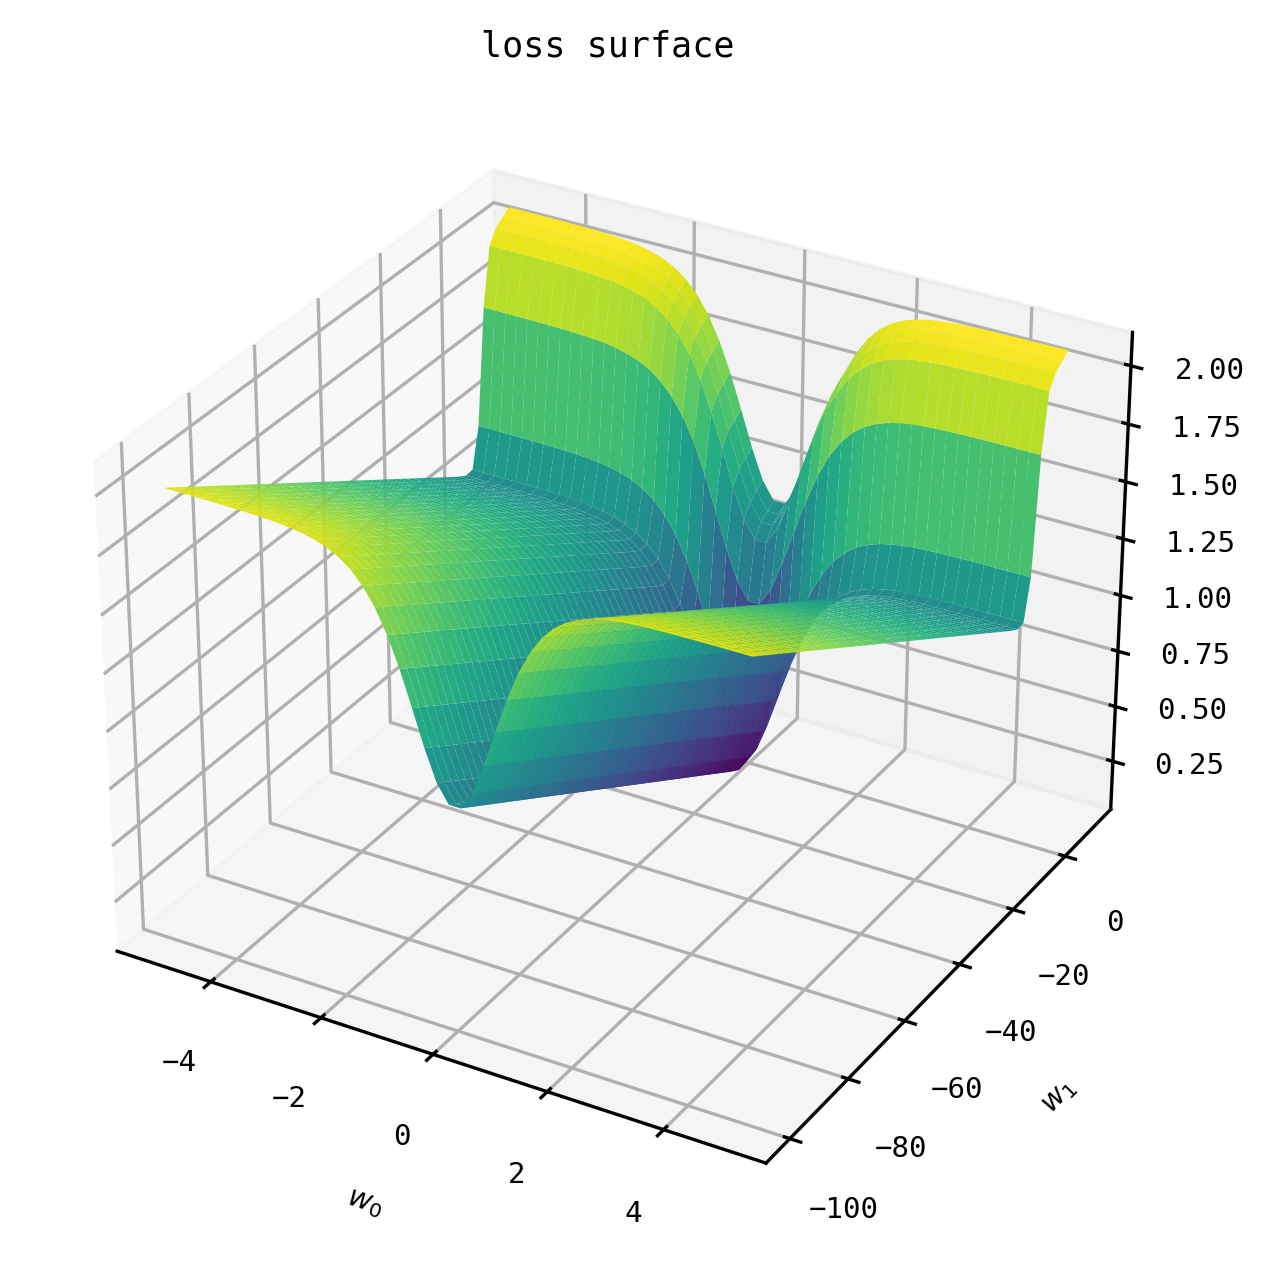

In [6]:
from okt.nbutils import set_plot_params
set_plot_params()

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 


def plot_surface(ax, f, title="", x_min=-5, x_max=5, y_min=-5, y_max=5, N=50):
    x = np.linspace(x_min, x_max, N)
    y = np.linspace(y_min, y_max, N)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    for i in range(N):
        for j in range(N):
            Z[i, j] = f(torch.tensor(X[i, j]), torch.tensor(Y[i, j]))
    
    ax.plot_surface(X, Y, Z, cmap="viridis")
    ax.set_xlabel(f"$w_0$")
    ax.set_ylabel(f"$w_1$")
    ax.set_title(title)
    

def plot_contourf(ax, f, w_hist, color, title="", levels=20, x_min=-5, x_max=5, y_min=-5, y_max=5, N=50, **kw):
    x = np.linspace(x_min, x_max, N)
    y = np.linspace(y_min, y_max, N)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    for i in range(N):
        for j in range(N):
            Z[i, j] = f(torch.tensor(X[i, j]), torch.tensor(Y[i, j]))

    for t in range(1, len(w_hist)):
        ax.plot([w_hist[t-1][0], w_hist[t][0]], [w_hist[t-1][1], w_hist[t][1]], color=color)

    ax.contourf(X, Y, Z, levels=levels, cmap="viridis")
    ax.scatter(w_hist[:, 0], w_hist[:, 1], marker="o", s=5, facecolors=color, color=color, **kw)
    ax.set_title(title)
    ax.set_xlabel(f"$w_0$")
    ax.set_ylabel(f"$w_1$")


fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')
plot_surface(ax, pathological_loss, x_min=-5, x_max=5, y_min=-100, y_max=10, title="loss surface");

**Figure.** This pathological loss surface [defined above](#pathological_loss) combines a long ravine with cliffs on both sides that plateaus above. This surface serves to test out the capabilities of variants of the gradient descent algorithm.

### GD simulation

The following optimization algorithm purely operates on the loss surface as a function of weights. 
It starts with initial weights `w_init`, then updates this weight iteratively by computing the
gradient of the loss function. The weight update step depends on the particular optimizer class used.

In [7]:
def train_curve(
    optim: OptimizerBase, 
    optim_params: dict, 
    w_init=[5.0, 5.0], 
    loss_fn=pathological_loss, 
    num_steps=100
):
    """Return trajectory of optimizer through loss surface from init point."""

    w_init = torch.tensor(w_init).float()
    w = nn.Parameter(w_init, requires_grad=True)
    optim = optim([w], **optim_params)
    points = [torch.tensor([w[0], w[1], loss_fn(w[0], w[1])])]
    
    for step in range(num_steps):
        optim.zero_grad()
        loss = loss_fn(w[0], w[1])
        loss.backward()
        optim.step()

        # logging
        with torch.no_grad():
            z = loss.unsqueeze(dim=0)
            points.append(torch.cat([w.data, z]))

    return torch.stack(points, dim=0).numpy()

In [8]:
def plot_gd_steps(ax, optim, optim_params: dict, label_map={}, w_init=[-2.5, 2.5], num_steps=300, **plot_kw):
    label = optim.__name__ + " (" + ", ".join(f"{label_map.get(k, k)}={v}" for k, v in optim_params.items()) + ")"
    path = train_curve(optim, optim_params, w_init=w_init, num_steps=num_steps)
    plot_contourf(ax[0], f=pathological_loss, w_hist=path, x_min=-10, x_max=10, y_min=-10, y_max=10, label=label, zorder=2, **plot_kw)
    ax[1].plot(np.array(path)[:, 2], label=label, color=plot_kw.get("color"), zorder=plot_kw.get("zorder", 1))
    ax[1].set_xlabel("steps")
    ax[1].set_ylabel("loss")
    ax[1].grid(linestyle="dotted", alpha=0.8)
    return path

Gradient descent from the same initial point with different learning rates:


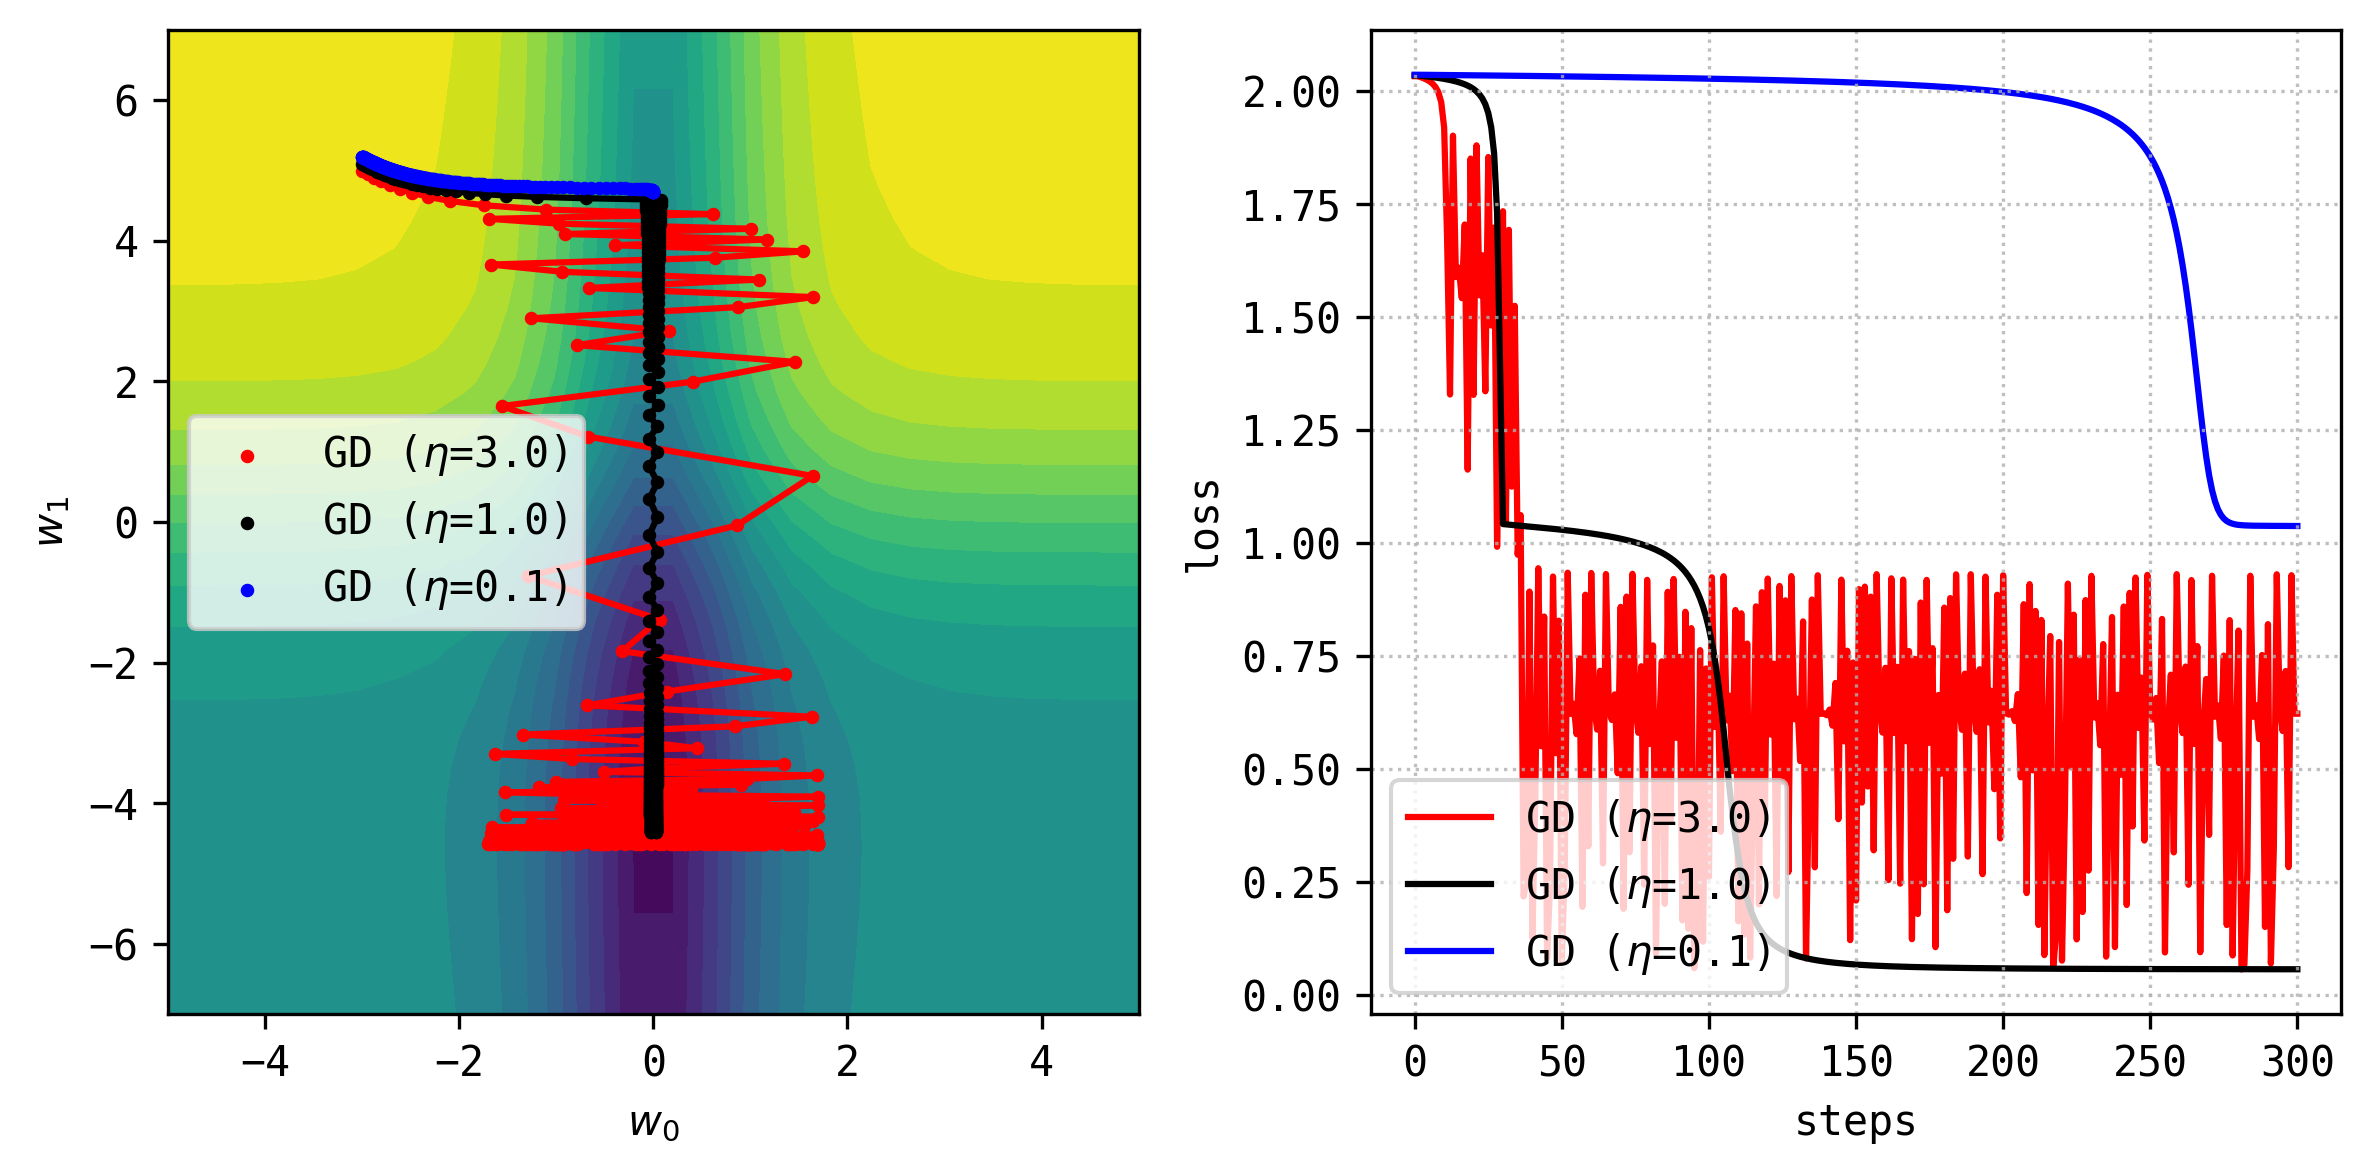

In [17]:
set_plot_params({"font.size": 10, "lines.linewidth": 1.5})

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

plot_gd_steps(ax, optim=GD, optim_params={"lr": 3.0}, w_init=[-3.0, 5.0], label_map={"lr": r"$\eta$"}, color="red")
plot_gd_steps(ax, optim=GD, optim_params={"lr": 1.0}, w_init=[-3.0, 5.1], label_map={"lr": r"$\eta$"}, color="black")
plot_gd_steps(ax, optim=GD, optim_params={"lr": 0.1}, w_init=[-3.0, 5.2], label_map={"lr": r"$\eta$"}, color="blue")

ax[0].set_xlim(-5, 5)
ax[0].set_ylim(-7, 7)
ax[0].legend()
ax[1].legend()

fig.tight_layout();

**Figure.** LR has to be tuned to avoid oscillations or getting stuck in plateaus shown here. Note that the optimal LR value depends on the initial point, so care must be taken with reproducibility during experiments.

## Characterizing the loss surface

For convex functions, gradient descent has strong guarantees of converging. However, the loss surface of neural networks
are generally nonconvex. Clever dimensionality reduction techniques allow us to visualize loss function curvature despite the very large number of parameters ({numref}`02-visualizing-loss` from {cite:p}`visualizing_loss`). Notice that there are **plateaus** (or flat minimas) and **local minimas** which makes gradient descent hard. In high-dimension **saddle points** are the most common critical points.

```{figure} ./img/02-visualizing-loss.png
---
name: 02-visualizing-loss
width: 80%
align: center
---
**The loss landscape.** The loss surfaces of ResNet-56 with (**right**) and without (**left**) skip connections. 
The loss surface on the right looks better although there are still some flatness. This example shows that optimization can be improved by improving the function instead of the optimizer. **Source:** {cite:p}`visualizing_loss`
```

+++

```{figure} ./img/02-optima-type.png
---
name: 02-optima-type
width: 100%
align: center
---
**Three types of critical points.** All are difficult with vanilla GD. [Source](https://cs182sp21.github.io/static/slides/lec-4.pdf)
```

### Local minima

Local minimas are very scary, in principle, since gradient descent could converge to a
solution that is *arbitrarily worse* than the global optimum. Surprisingly, this becomes 
less of an issue as the number of parameters increases, as they 
tend to be not much worse than global optima. {numref}`02-local-minima`
below shows that for larger networks the test loss variance between training 
runs become
smaller. This indicates that local minima tend to be increasingly equivalent 
as we increase network size.

```{figure} ./img/02-local-minima.png
---
name: 02-local-minima
width: 80%
align: center
---
**Mean local minima shifts toward lower values, with decreasing variance.** 
Test loss of 1000 networks on a scaled-down version of MNIST, where
each image was downsampled to size 10×10. The networks have one hidden layer
and with 25, 50, 100, 250, and 500 hidden units, 
each one starting from a random set of parameters sampled uniformly within the unit cube. 
All networks were trained for 200 epochs using SGD with
learning rate decay. **Source:** {cite:p}`pmlr-v38-choromanska15`
```

### Plateaus

Plateaus are regions in the loss landscape with small gradients. It can also be a flat local minima. Below the initial weights is in a plateau, and the optimizer with small learning rate gets stuck and fails to converge. Large learning rate allows the optimizer to escape such regions. As such, we cannot simply choose small learning rate to prevent oscillations.

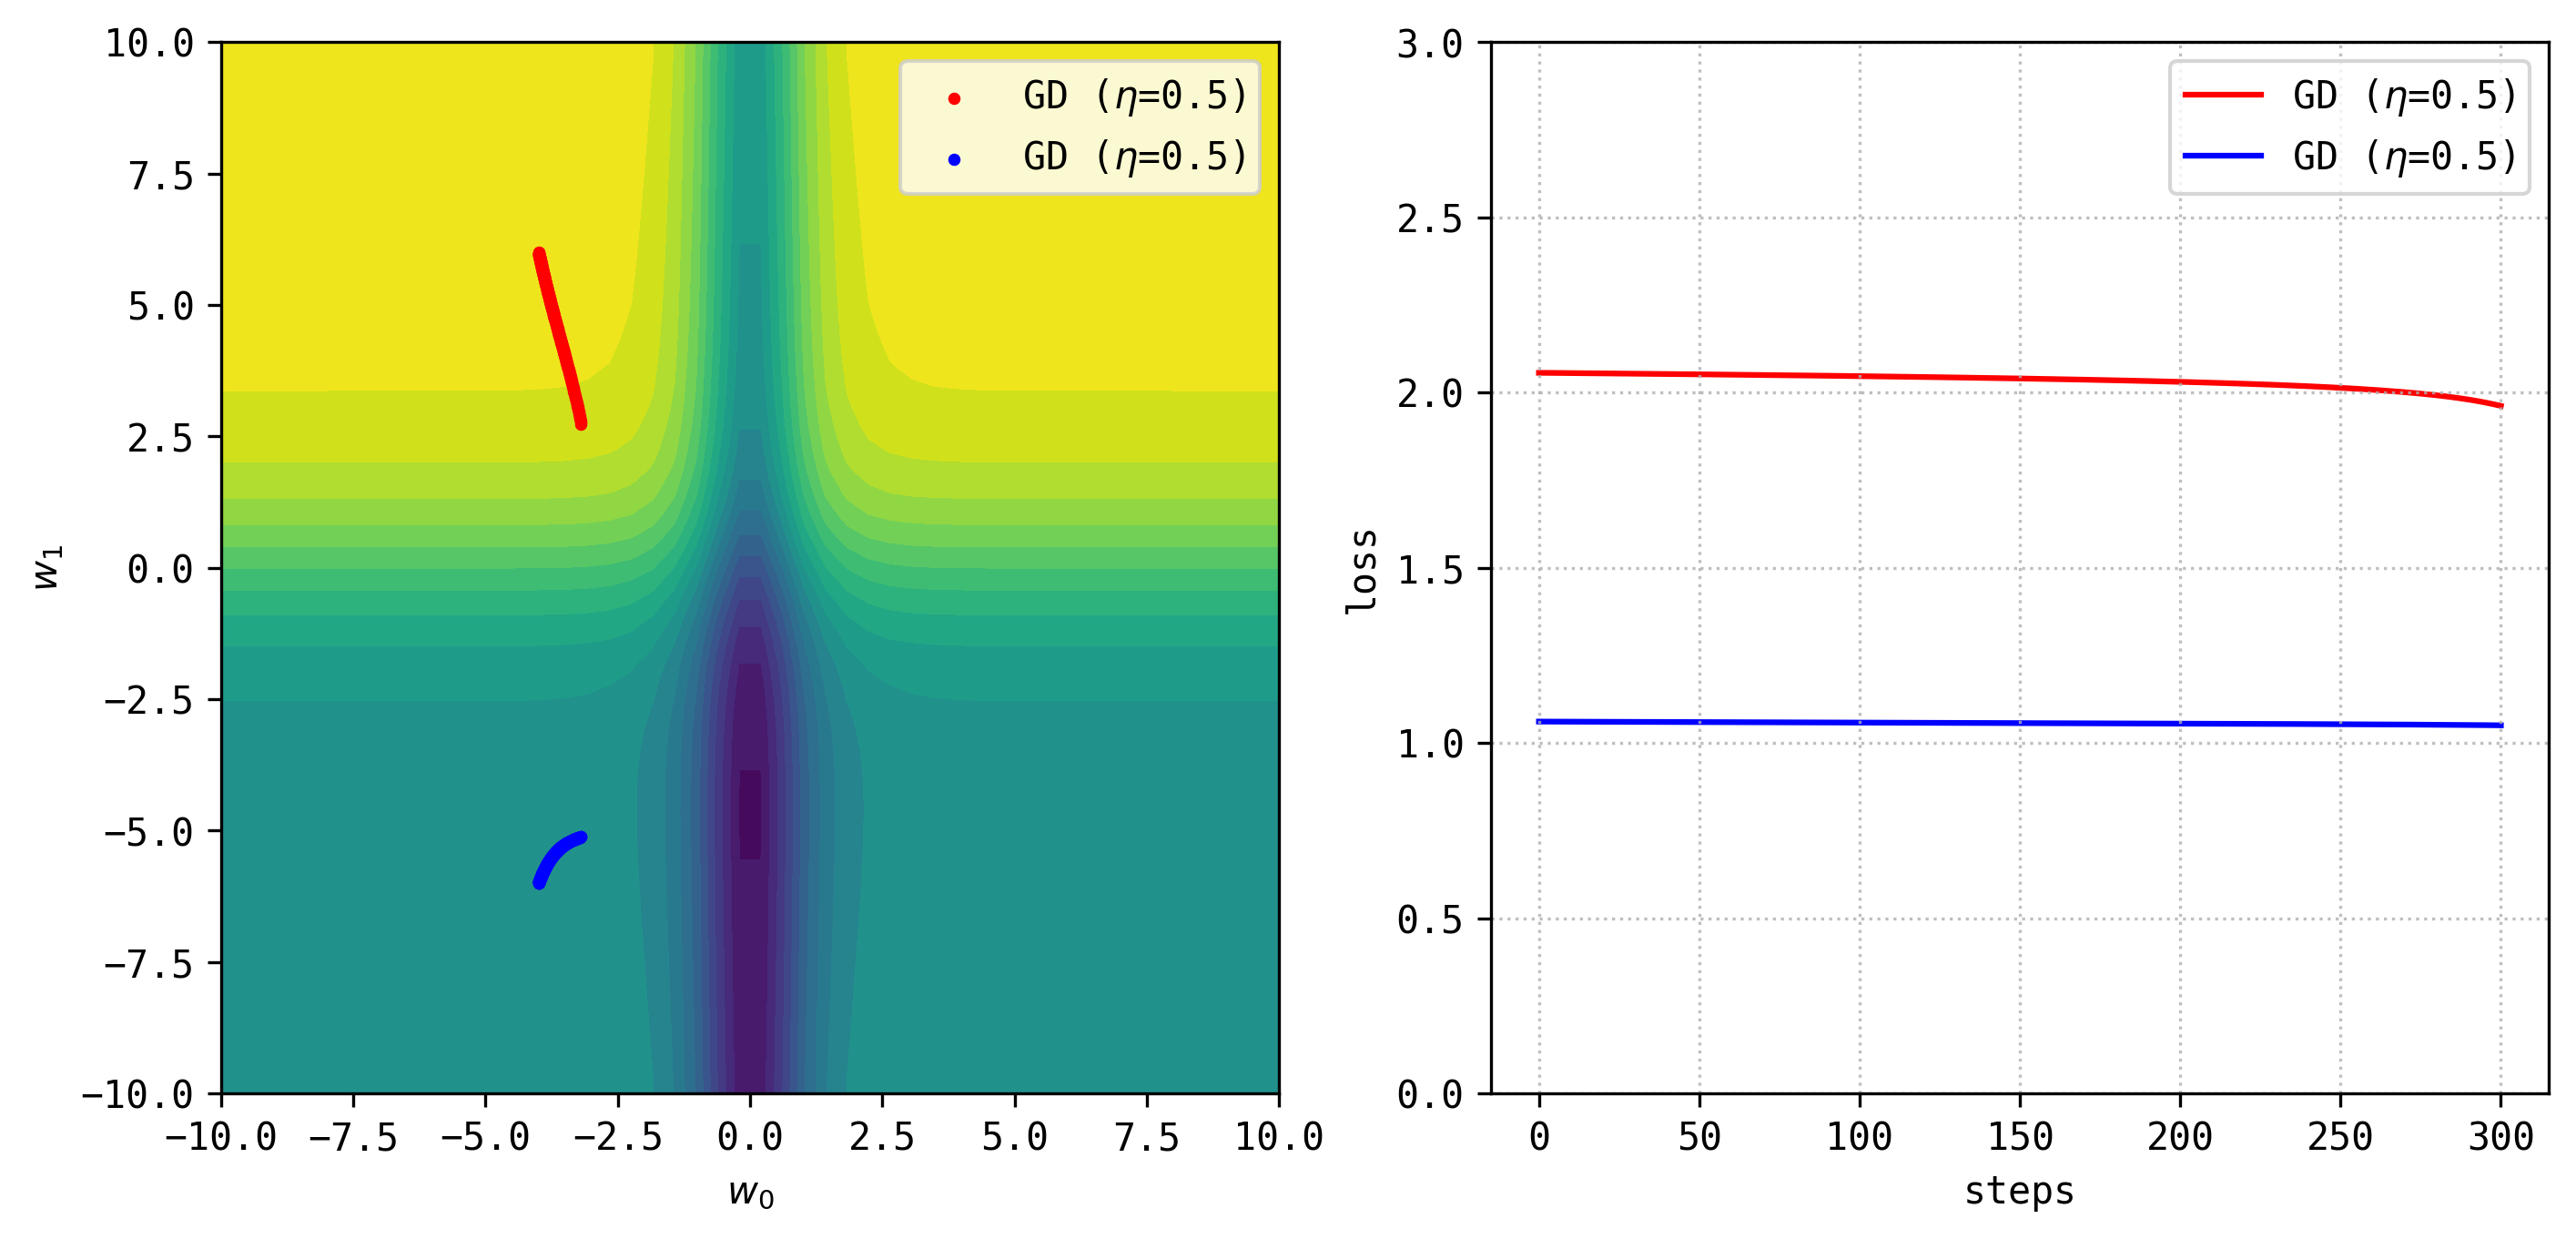

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
plot_gd_steps(ax, optim=GD, optim_params={"lr": 0.5}, w_init=[-4.0,  6.0], label_map={"lr": r"$\eta$"}, color="red")
plot_gd_steps(ax, optim=GD, optim_params={"lr": 0.5}, w_init=[-4.0, -6.0], label_map={"lr": r"$\eta$"}, color="blue")

ax[1].set_ylim(0, 3)
ax[0].legend()
ax[1].legend();

### Saddle points

Saddle points are critical points (i.e. gradient zero) that are local minimum in some dimensions but local maximum in other dimensions. Neural networks have a lot of symmetry which can result in exponentially many local minima. Saddle points naturally arise
in paths that connect these local minima ({numref}`02-connected-minima`). 
It takes a long time to escape a saddle point since it is usually surrounded by high-loss plateaus {cite:p}`dauphin2014`.
A saddle point looks like a special structure. But in high-dimension, it turns out that most optima are saddle points.

```{figure} ./img/02-connected-minima.png
---
name: 02-connected-minima
width: 60%
align: center
---
**Saddle point.** Paths between two minimas result in a saddle point. [Source](https://www.offconvex.org/2016/03/22/saddlepoints/)
```

The Hessian $\boldsymbol{\mathsf{H}}$ at the critical point of a surface is a matrix containing second derivatives at that point. We will see shortly that these characterize the local curvature. From [Schwarz's theorem](https://en.wikipedia.org/wiki/Symmetry_of_second_derivatives#Schwarz's_theorem), mixed partials are equal assuming the second partial derivatives are continuous around the optima. It follows that $\boldsymbol{\mathsf{H}}$ is symmetric, and from the [Real Spectral Theorem](https://github.com/particle1331/computational-linear-algebra/blob/master/chapters/02-svd.ipynb), $\boldsymbol{\mathsf{H}}$ is diagonalizable with real eigenvalues. It turns out that local curvature is characterized by whether the eigenvalues are negative, zero, or positive.

If all eigenvalues of the Hessian are positive, it is [positive-definite](https://en.wikipedia.org/wiki/Definite_matrix), i.e. $\boldsymbol{\mathsf{x}}^\top \boldsymbol{\mathsf{H}}\, \boldsymbol{\mathsf{x}} > 0$ for $\boldsymbol{\mathsf{x}} \neq \boldsymbol{0}.$ This follows directly from the spectral decomposition $\boldsymbol{\mathsf{H}} = \boldsymbol{\mathsf{U}} \boldsymbol{\Lambda} \boldsymbol{\mathsf{U}}^\top$ such that $\boldsymbol{\Lambda}$ is the diagonal matrix of eigenvalues of $\boldsymbol{\mathsf{H}}$ and $\boldsymbol{\mathsf{U}}$ is an orthogonal matrix with corresponding unit eigenvectors as columns. This is the multivariable equivalent of **concave up**. On the other hand, if all eigenvalues of $\boldsymbol{\mathsf{H}}$ are negative, then it is negative-definite or **concave down**. To see this, observe that the Taylor expansion at the critical point is:

$$
\Delta \mathcal{L}_{\mathcal{D}} = \frac{1}{2} \Delta \boldsymbol{\Theta}^\top \boldsymbol{\mathsf{H}}\, \Delta \boldsymbol{\Theta} + O(\Delta \boldsymbol{\Theta}^3).
$$

If any eigenvalue is zero, more information is needed (i.e. we need third order terms). Finally, if the eigenvalues are mixed, we get a **saddle point** where there are orthogonal directions corresponding to eigenvectors where the loss decreases and directions where the loss increases. Getting $M = |\boldsymbol{\Theta}|$ eigenvalues of the same sign or having one zero eigenvalue is relatively rare for large networks with complex loss surfaces, so that the probability that the critical point is a saddle point is high.


## Momentum methods

### Momentum

Recall that high learning rate allows the optimizer to overcome plateaus. However, this can result in oscillation. The intuition behind **momentum** is that if successive gradient steps point in different
directions, we should cancel off the directions that disagree. Moreover, if successive gradient steps point in similar directions, we
should go faster in that direction. Simply adding gradients can result in extreme step size, so exponential averaging using a parameter $0 \leq \beta < 1$ is used:

$$
\begin{aligned}
\boldsymbol{\mathsf{m}}^t &= \beta \, \boldsymbol{\mathsf{m}}^{t-1} + (1 - \beta) \, \nabla_{\boldsymbol{\Theta}}\, f(\boldsymbol{\Theta}^{t}) \\
\boldsymbol{\boldsymbol{\Theta}}^{t+1} &= \boldsymbol{\boldsymbol{\Theta}}^{t} - \eta \, \boldsymbol{\mathsf{m}}^{t}.
\end{aligned}
$$

Note that $\beta = 0$ is just regular GD.
In the following implementation, we add an extra parameter `momentum=0.0` to the `GD` class for $\beta$. Observe that the optimizer is now **stateful**[^1]: the attribute `self.m` stores the momentum vector $\boldsymbol{\mathsf{m}}^t$ above as a dictionary with parameter keys. We will set $\boldsymbol{\mathsf{m}}^0 = \boldsymbol{0}$ and $\boldsymbol{\Theta}^1 = \boldsymbol{\Theta}_{\text{init}}.$

In [19]:
class GDM(OptimizerBase):
    def __init__(self, params, lr, momentum=0.0):
        super().__init__(params, lr)
        self.beta = momentum
        self.m = {p: torch.zeros_like(p.data) for p in self.params}

    def update_param(self, p):
        self.m[p] = self.beta * self.m[p] + (1 - self.beta) * p.grad
        p += -self.lr * self.m[p]

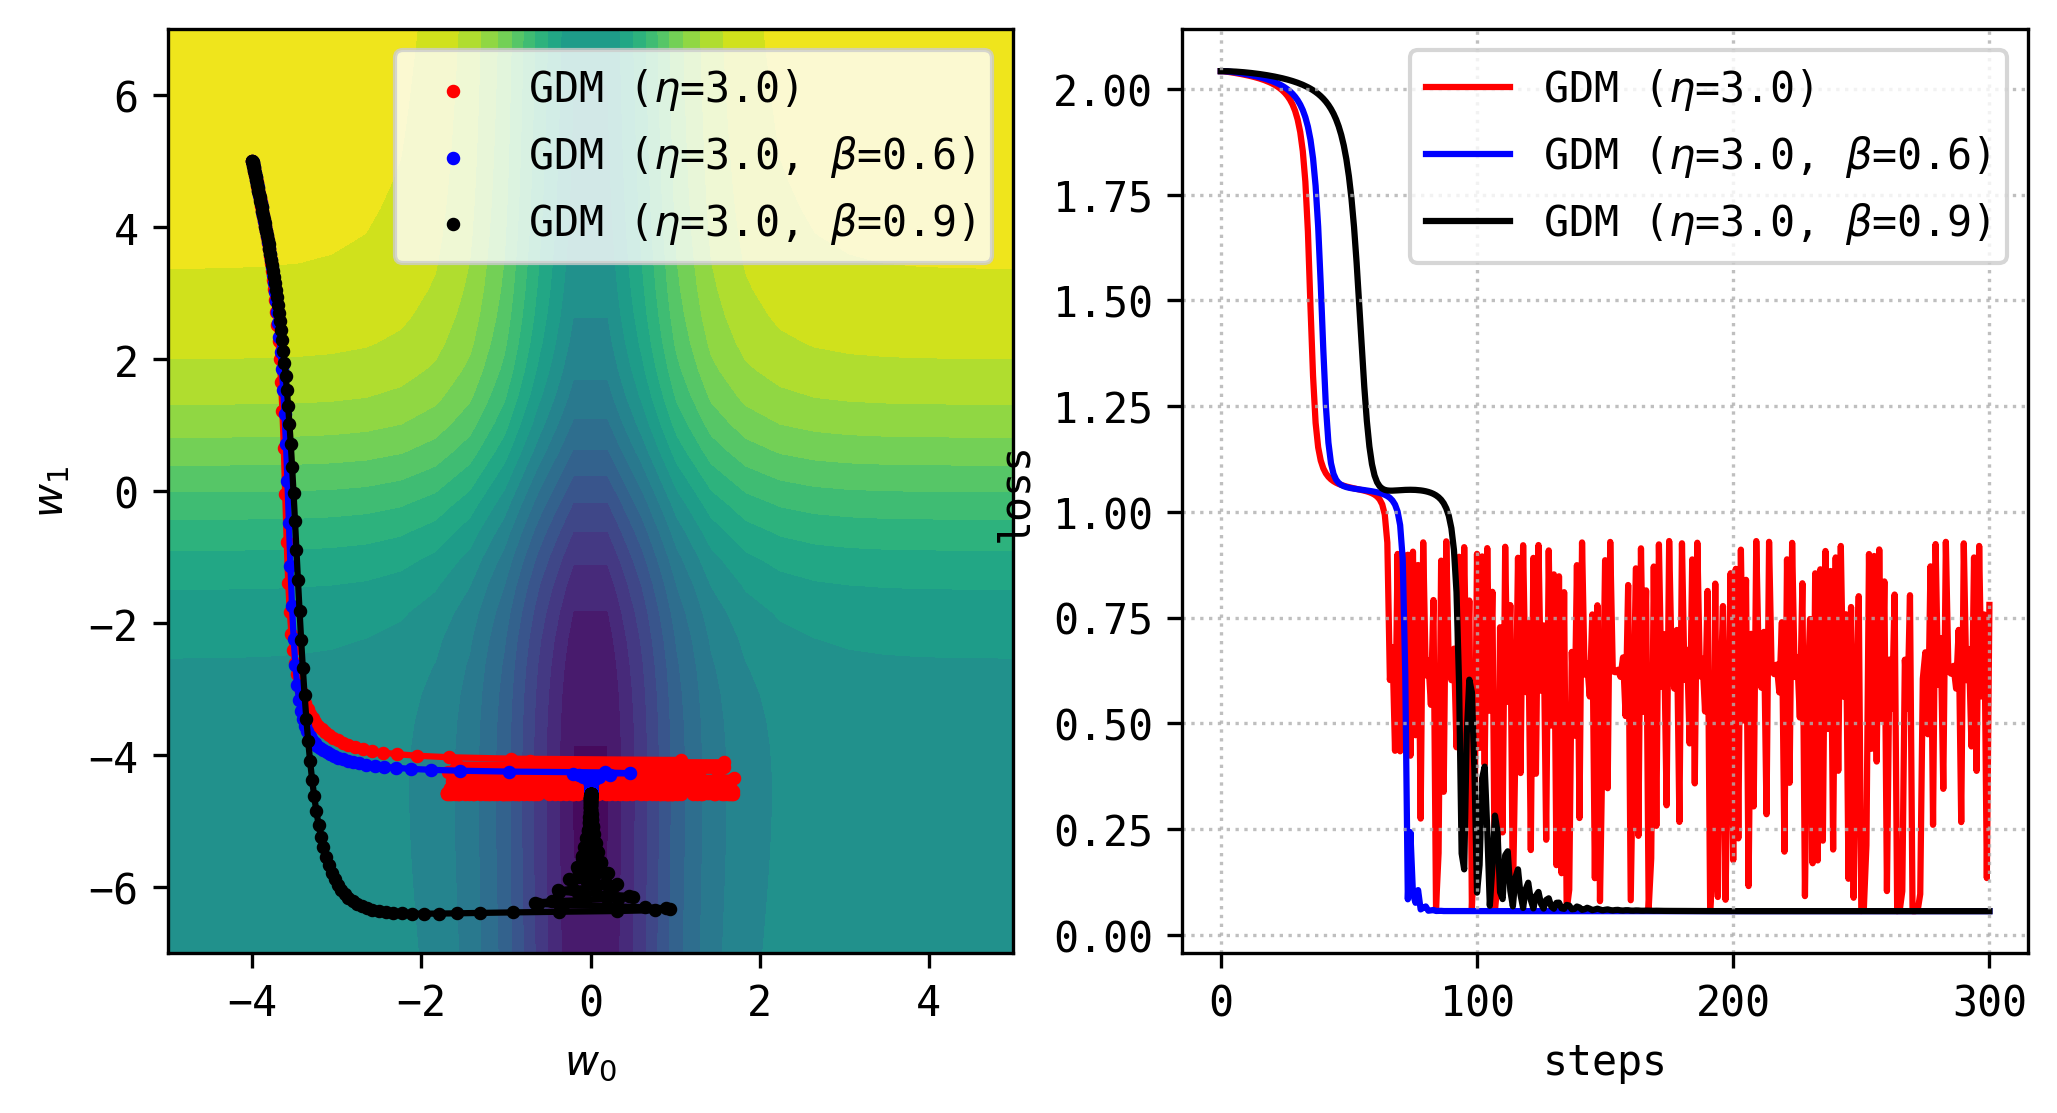

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[1].grid(linestyle="dotted", alpha=0.6, zorder=5)

label_map_gdm = {"lr": r"$\eta$", "momentum": r"$\beta$"}
plot_gd_steps(ax, optim=GDM, optim_params={"lr": 3.0},                  w_init=[-4.0, 5.0], label_map=label_map_gdm, color="red")
plot_gd_steps(ax, optim=GDM, optim_params={"lr": 3.0, "momentum": 0.6}, w_init=[-4.0, 5.0], label_map=label_map_gdm, color="blue");
plot_gd_steps(ax, optim=GDM, optim_params={"lr": 3.0, "momentum": 0.9}, w_init=[-4.0, 5.0], label_map=label_map_gdm, color="black");

ax[0].set_xlim(-5, 5)
ax[0].set_ylim(-7, 7)
ax[1].set_xlabel("steps")
ax[1].set_ylabel("loss")
ax[0].legend()
ax[1].legend();

^**Momentum dampens oscillation around the minimum.** The parameter $\beta$ controls the effect of the previous update to the current update vector. A large momentum means that it maintains the previous state much more, while the gradient at the current point $(\boldsymbol{\Theta}^t, \mathcal{L}(\boldsymbol{\Theta^t}))$ has less effect on the update vector. The optimizer with higher $\beta$ overshot the minimum.

[^1]: Saving the `state_dict` for the optimizer and model in PyTorch allows to [resume training](https://pytorch.org/tutorials/beginner/saving_loading_models.html#saving-loading-a-general-checkpoint-for-inference-and-or-resuming-training).

### RMSProp

In vanilla GD, the magnitude of gradient is not very informative, only its *sign* is. 
Near the minimum it becomes small 
slowing down convergence, and on sharp slopes it can blow up the gradient vector. 
This makes it difficult to tune learning rate for different functions, or for different
points on the same function. To fix this, 
**RMSProp** normalizes the gradient along each dimension. 
It estimates the size of the gradient using exponential averaging with $\boldsymbol{\mathsf{v}}^0 = \mathbf{0}$ and $\boldsymbol{\Theta}^1 = \boldsymbol{\Theta}_{\text{init}}$:

$$
\begin{aligned}
\boldsymbol{\mathsf{v}}^t &= \beta \, \boldsymbol{\mathsf{v}}^{t-1} + (1 - \beta) \, \left( \nabla_{\boldsymbol{\Theta}}\, f(\boldsymbol{\Theta}^{t}) \right)^2 \\
\boldsymbol{\boldsymbol{\Theta}}^{t+1} &= \boldsymbol{\boldsymbol{\Theta}}^{t} - \eta \, \frac{1}{\sqrt{\boldsymbol{\mathsf{v}}^{t}}} \odot \nabla_{\boldsymbol{\Theta}}\, f(\boldsymbol{\Theta}^{t}).
\end{aligned}
$$

In [35]:
class RMSProp(OptimizerBase):
    def __init__(self, params, lr, beta=0.9):
        super().__init__(params, lr)
        self.beta = beta
        self.v = {p: torch.zeros_like(p.data) for p in self.params}

    def update_param(self, p):
        self.v[p] = self.beta * self.v[p] + (1 - self.beta) * p.grad ** 2
        p += -self.lr * p.grad / torch.sqrt(self.v[p])

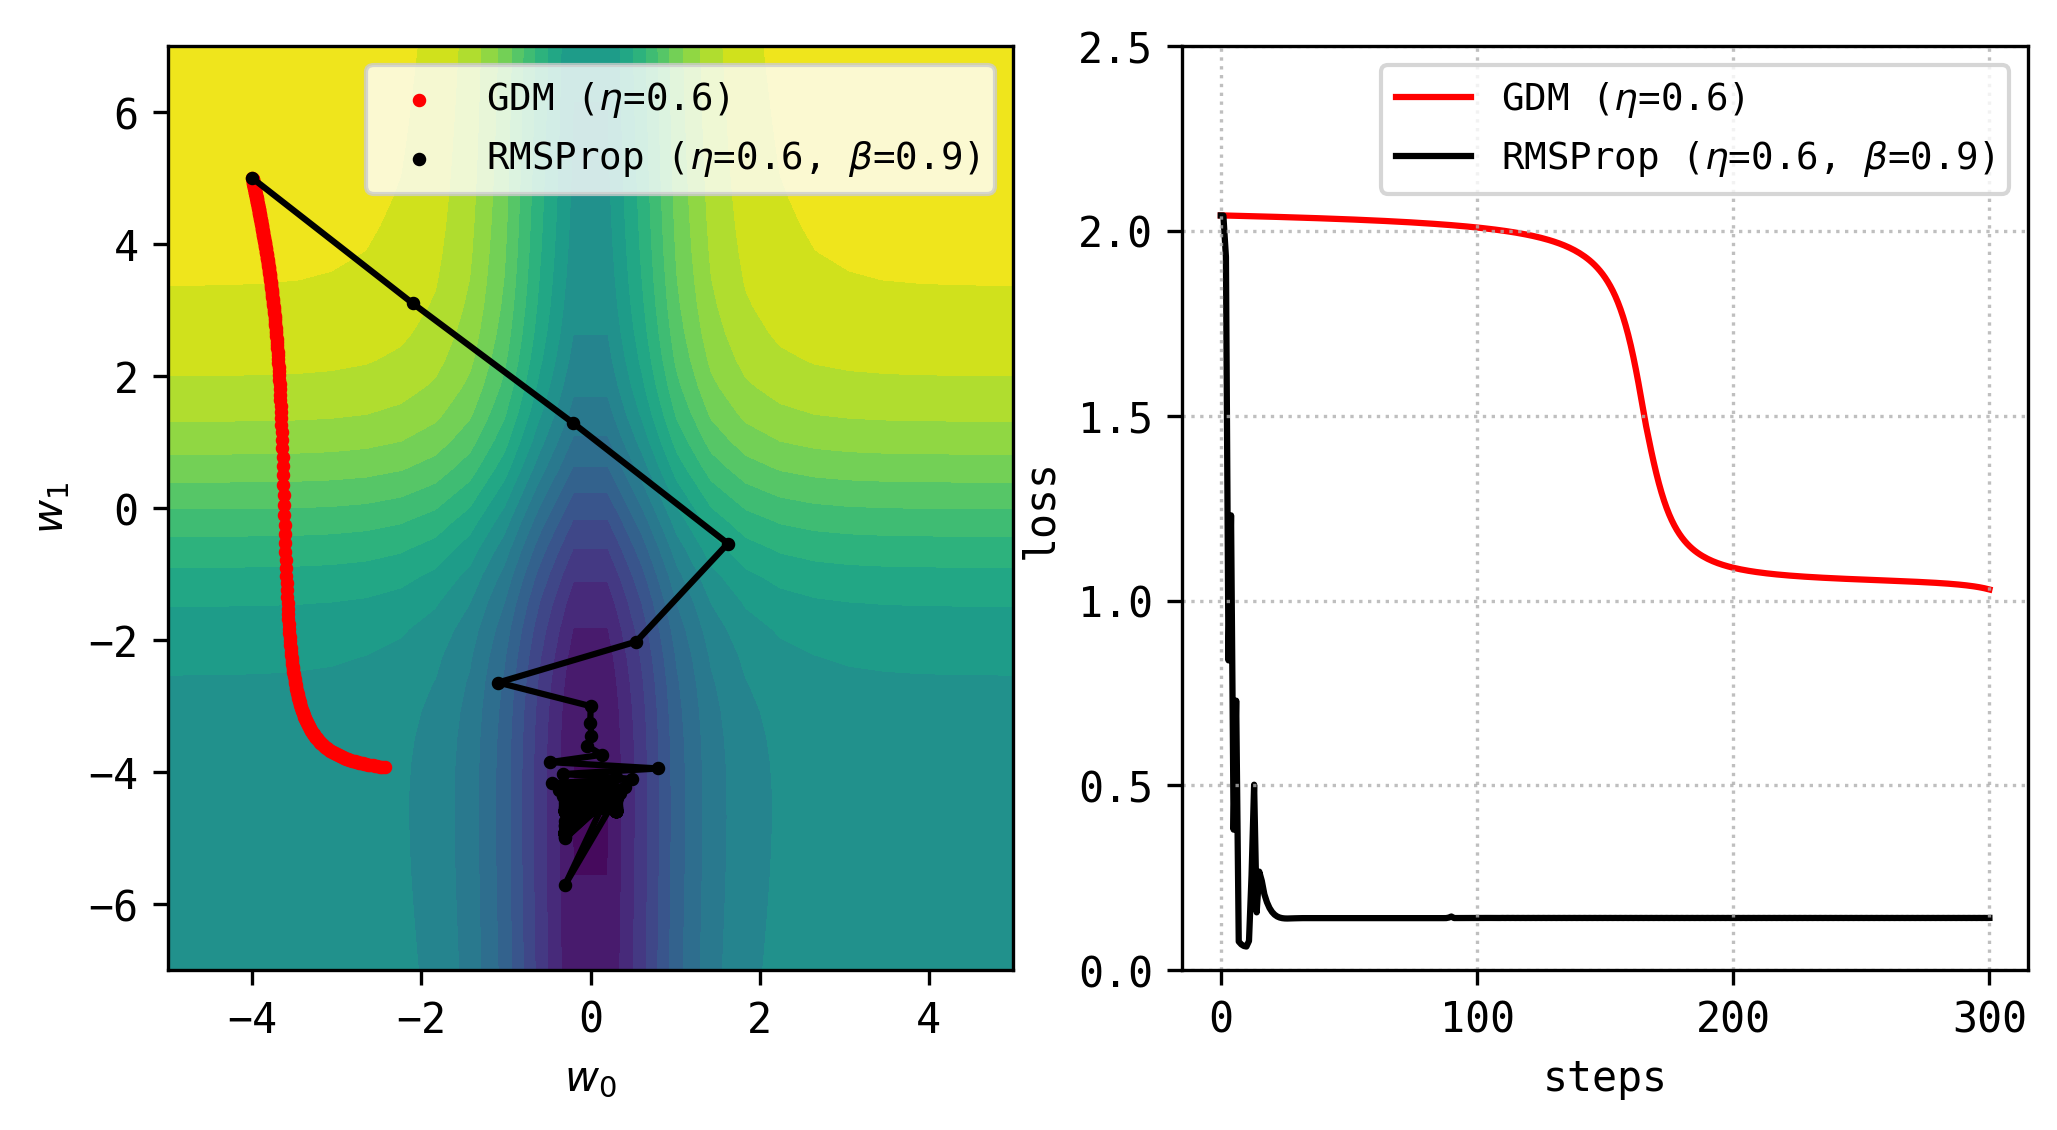

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
label_map_rmsprop = {"lr": r"$\eta$", "beta": r"$\beta$"}
plot_gd_steps(ax, optim=GDM,     optim_params={"lr": 0.6},              w_init=[-4.0, 5.0], label_map=label_map_gdm,     color="red")
plot_gd_steps(ax, optim=RMSProp, optim_params={"lr": 0.6, "beta": 0.9}, w_init=[-4.0, 5.0], label_map=label_map_rmsprop, color="black")

ax[0].set_xlim(-5, 5)
ax[0].set_ylim(-7, 7)
ax[1].set_xlabel("steps")
ax[1].set_ylabel("loss")
ax[1].grid(linestyle="dotted", alpha=0.8)
ax[0].legend(fontsize=9)
ax[1].set_ylim(0, 2.5)
ax[1].legend(fontsize=9);

^**Adaptive gradient steps escape plateaus.** The initial step size is ${\eta} \, {({1 - \beta})^{-1/2}} \geq \eta$ in each direction. Above, when the gradient is smaller than previous gradients, the step size suddenly becomes small. This can be observed a few steps before the minimum. Conversely, if the gradient is larger than previous gradients, then $\frac{1}{\sqrt{\boldsymbol{\mathsf{v}}^{t}}} \nabla_{\boldsymbol{\Theta}}\, f(\boldsymbol{\Theta}^{t})$ is large. This again can be observed near the minimumm, after the steps become small. 

**Remark.** RMSProp have erratic properties, nevertheless it exhibits **adaptive learning rates**. That is, it looks like regular gradient descent but with dynamic effective learning rate in each parameter direction. 
Adam below uses adaptive LR and improves upon the defects of RMSProp.

### Adam

Observe in the above figure that RMSProp oscillates around the minimum. **Adam** {cite:p}`adam` fixes this by combining momentum with RMSProp. Adam uses bias correction so that gradients dominate during early stages of training, instead of the state vectors which are initially set to zero, these will have less  influence as training progresses. Let $0 \leq \beta_1 < 1$, $0 \leq \beta_2 < 1$, and $0 < \epsilon \ll 1.$ Set $\boldsymbol{\mathsf{m}}^0 = \boldsymbol{\mathsf{v}}^0  = \mathbf{0}$ and $\boldsymbol{\Theta}^1 = \boldsymbol{\Theta}_{\text{init}}.$ Starting with $t = 1$:

$$
\begin{aligned}
\boldsymbol{\mathsf{m}}^t &= \beta_1 \, \boldsymbol{\mathsf{m}}^{t-1} + (1 - \beta_1) \, \nabla_{\boldsymbol{\Theta}}\, f(\boldsymbol{\Theta}^{t}) \\
\boldsymbol{\mathsf{v}}^t &= \beta_2 \, \boldsymbol{\mathsf{v}}^{t-1} + (1 - \beta_2) \, \left( \nabla_{\boldsymbol{\Theta}}\, f(\boldsymbol{\Theta}^{t}) \right)^2 \\
\hat{\boldsymbol{\mathsf{m}}}^t &= \frac{\boldsymbol{\mathsf{m}}^t}{1 - {\beta_1}^t} \\
\hat{\boldsymbol{\mathsf{v}}}^t &= \frac{\boldsymbol{\mathsf{v}}^t}{1 - {\beta_2}^t} \\
\boldsymbol{\boldsymbol{\Theta}}^{t+1} &= \boldsymbol{\boldsymbol{\Theta}}^{t} - \eta \, \frac{1}{\sqrt{\hat{\boldsymbol{\mathsf{v}}}^{t}} + \epsilon} \odot \hat{\boldsymbol{\mathsf{m}}}^t.
\end{aligned}
$$

Sensible defaults are $\eta = 0.001$, $\beta_1 = 0.9$, $\beta_2 = 0.999$ and $\epsilon = 10^{-8}.$ 
Having $\beta_2 > \beta_1$
ensures that the learning rate adjustment, based on the accumulated squared gradients, is smooth and does not fluctuate too rapidly. This stability is crucial for effective learning, especially in noisy or sparse data environments, where the gradients can vary significantly. At the same time, a lower $\beta_1$ ensures responsiveness in momentum calculations. Note that similar to RMSProp, the effective update size auto-tunes, but since it tunes the momentum (instead of the gradient), the updates are more stable. Finally, the learning rate $\eta$ is roughly the update size in each dimension in a stable regime.

**Bias correction.** Let $\boldsymbol{\mathsf{g}}^t = \nabla_{\boldsymbol{\Theta}}\, f(\boldsymbol{\Theta}^{t}).$ Note that time $t = 1$ corresponds to the initial point in the loss surface where $\boldsymbol{\mathsf{g}}^1 = \nabla_{\boldsymbol{\Theta}}\, f(\boldsymbol{\Theta}_{\text{init}})$. This also means that $t$ is the number of gradients that are summed when computing the exponential average. Observe that 

$$
\begin{aligned}
\boldsymbol{\mathsf{m}}^1
&= (1 - \beta_1)\, \boldsymbol{\mathsf{g}}^1\\\\
\boldsymbol{\mathsf{m}}^2
&= \beta_1\, \boldsymbol{\mathsf{m}}^1 + (1 - \beta_1)\, \boldsymbol{\mathsf{g}}^2 \\
&= \beta_1\, (1 - \beta_1)\, \boldsymbol{\mathsf{g}}^1 + (1 - \beta_1)\, \boldsymbol{\mathsf{g}}^2\\
&= (1 - \beta_1) \left({\beta_1}\,\boldsymbol{\mathsf{g}}^1 + \boldsymbol{\mathsf{g}}^2 \right).\\\\
\boldsymbol{\mathsf{m}}^3 
&= \beta_1\, \boldsymbol{\mathsf{m}}^2 + (1 - \beta_1)\, \boldsymbol{\mathsf{g}}^3 \\
&= \beta_1\, (1 - \beta_1)\,(\beta_1  \, \boldsymbol{\mathsf{g}}^1 +  \, \boldsymbol{\mathsf{g}}^2) + (1 - \beta_1)\, \boldsymbol{\mathsf{g}}^3\\
&= (1 - \beta_1) \left({\beta_1}^2 \boldsymbol{\mathsf{g}}^1 + {\beta_1}\, \boldsymbol{\mathsf{g}}^2 + \boldsymbol{\mathsf{g}}^3 \right).\\
\end{aligned}
$$

This slows down training at early steps where the terms in the sum are few, so that $\boldsymbol{\mathsf{m}}^t$ is small. Recall that $(1 - {\beta_1}^{3}) = (1 - {\beta_1}) \sum_{t = 0}^2 {\beta_1}^t.$ Dividing with this gets us a proper average that is biased towards recent gradients:

$$
\begin{aligned}
\hat{\boldsymbol{\mathsf{m}}}^3 &= \frac{{\beta_1}^2 \boldsymbol{\mathsf{g}}^1 + {\beta_1}\, \boldsymbol{\mathsf{g}}^2 + \boldsymbol{\mathsf{g}}^3}{{\beta_1}^2 + {\beta_1} + 1}.\\
\end{aligned}
$$

This calculation extends inductively. For $t = 1$, $\boldsymbol{\mathsf{m}}^1 = (1 - \beta_1)\,\boldsymbol{\mathsf{g}}^1$ whereas with bias correction we get $\hat{\boldsymbol{\mathsf{m}}}^1 = \boldsymbol{\mathsf{g}}^1.$ The following implementation gets this right with `self.t = 1` at the initial point where we apply the first update step. Note that bias correction in momentum only works because of the auto-learning rate tuning with $1 / \sqrt{\hat{\boldsymbol{\mathsf{v}}}^t}$. Otherwise, the optimizer rolls down a slope too fast, missing the minimum!

In [38]:
class Adam(OptimizerBase):
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        super().__init__(params, lr)
        self.beta1 = beta1
        self.beta2 = beta2
        self.t = 0
        self.m = {p: torch.zeros_like(p.data) for p in self.params}
        self.v = {p: torch.zeros_like(p.data) for p in self.params}
        self.eps = eps

    @torch.no_grad()
    def step(self):
        """Increment global time for each optimizer step."""
        self.t += 1
        OptimizerBase.step(self)

    def update_param(self, p):
        self.m[p] = self.beta1 * self.m[p] + (1 - self.beta1) * p.grad
        self.v[p] = self.beta2 * self.v[p] + (1 - self.beta2) * p.grad ** 2
        m_hat = self.m[p] / (1 - self.beta1 ** self.t)
        v_hat = self.v[p] / (1 - self.beta2 ** self.t)
        p += -self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

Running with $\eta = 0.3$:

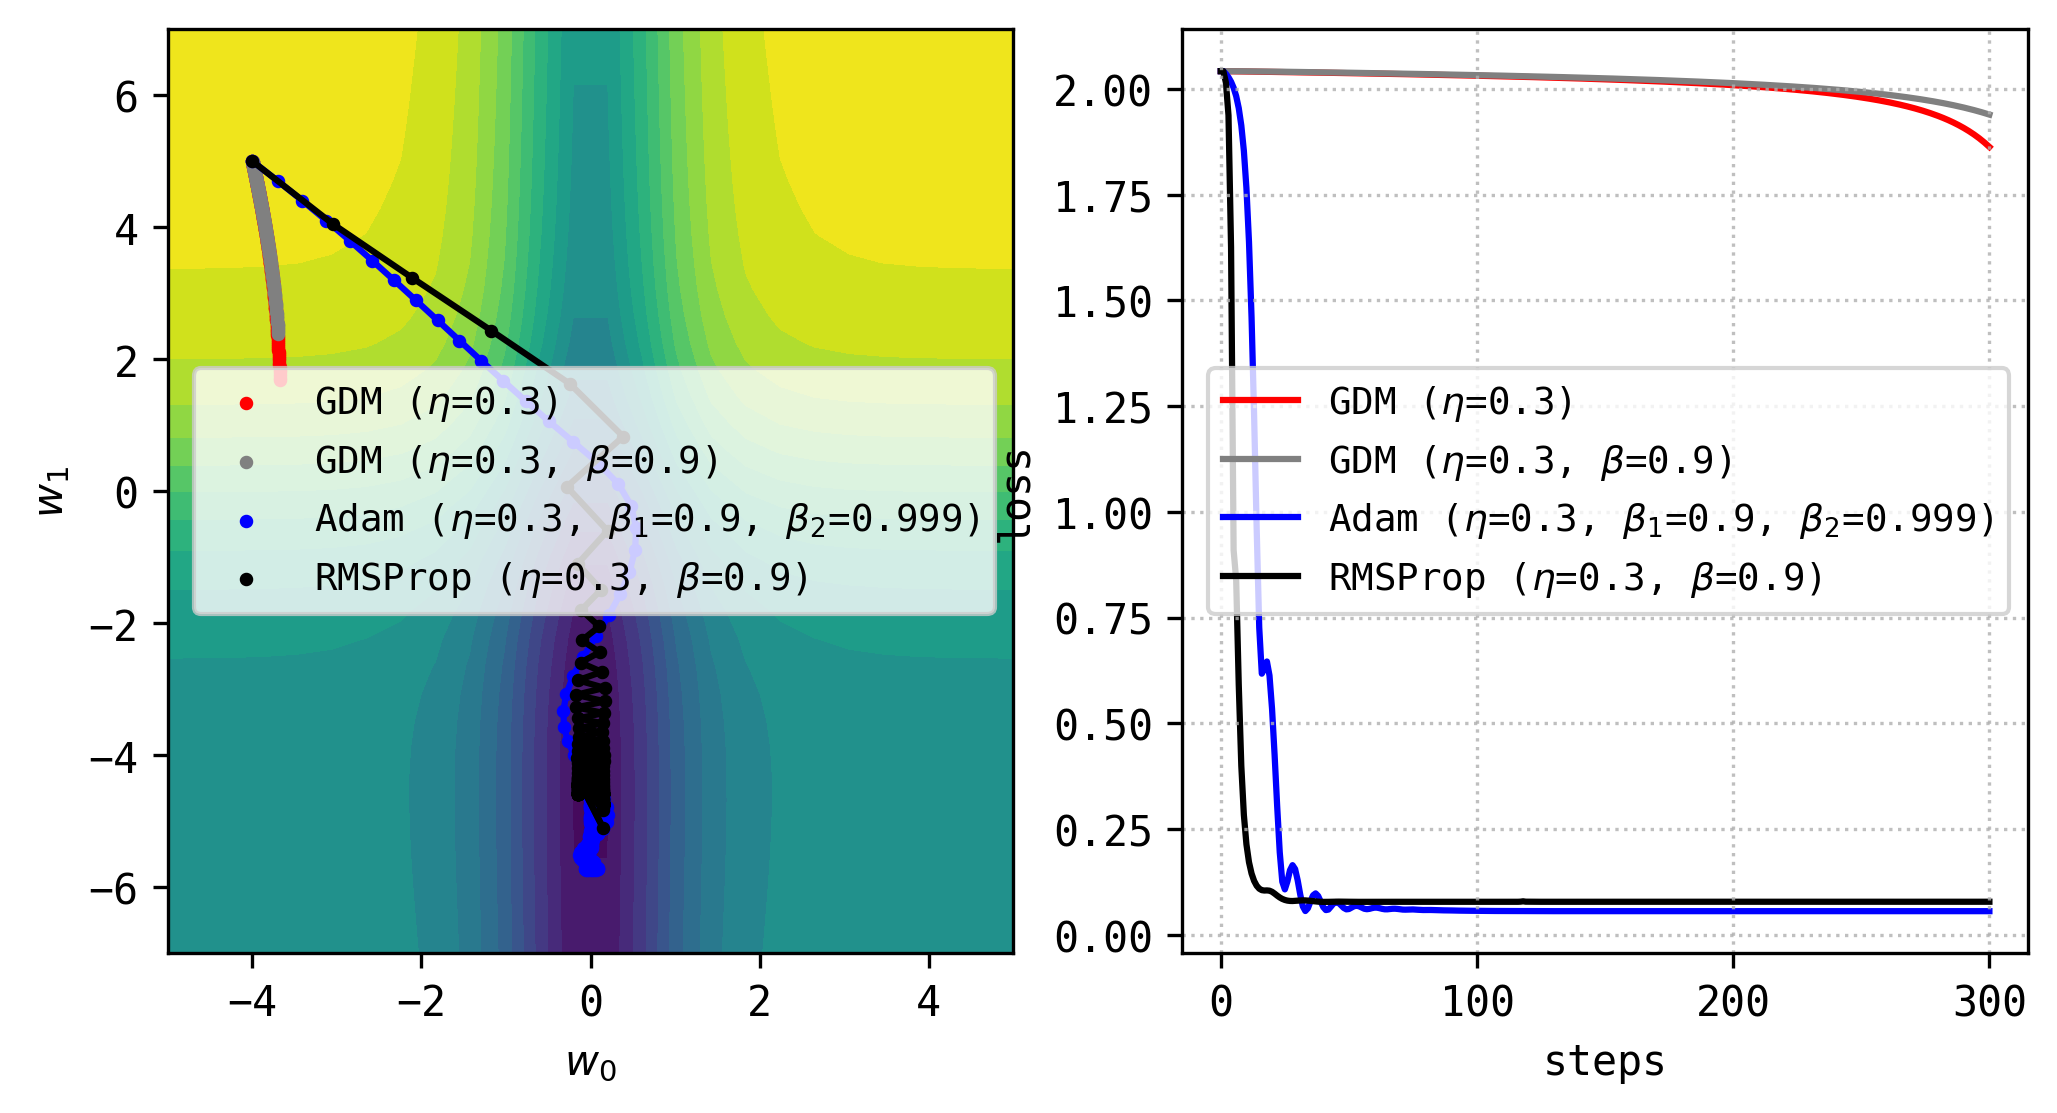

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
label_map_adam = {"lr": r"$\eta$", "beta1": r"$\beta_1$", "beta2": r"$\beta_2$"}
plot_gd_steps(ax, optim=GDM,     optim_params={"lr": 0.3},                               w_init=[-4.0, 5.0], label_map=label_map_gdm,     color="red")
plot_gd_steps(ax, optim=GDM,     optim_params={"lr": 0.3, "momentum": 0.9},              w_init=[-4.0, 5.0], label_map=label_map_gdm,     color="gray")
plot_gd_steps(ax, optim=Adam,    optim_params={"lr": 0.3, "beta1": 0.9, "beta2": 0.999}, w_init=[-4.0, 5.0], label_map=label_map_adam,    color="blue")
plot_gd_steps(ax, optim=RMSProp, optim_params={"lr": 0.3, "beta": 0.9},                  w_init=[-4.0, 5.0], label_map=label_map_rmsprop, color="black")

ax[0].set_xlim(-5, 5)
ax[0].set_ylim(-7, 7)
ax[1].set_xlabel("steps")
ax[1].set_ylabel("loss")
ax[1].grid(linestyle="dotted", alpha=0.8)
ax[0].legend(fontsize=9)
ax[1].legend(fontsize=9);

^**Momentum in Adam dampens oscillations.** Observe that for RMSProp, the oscillations do not die out near the minimum. Moreover, at the start of training where gradient updates do not cancel out, Adam has a step size of $\eta$ in each direction. Then, adaptive learning rate later helps to regulate the step size as the gradient tends to zero around the minimum.

Increasing learning rate by 8x:

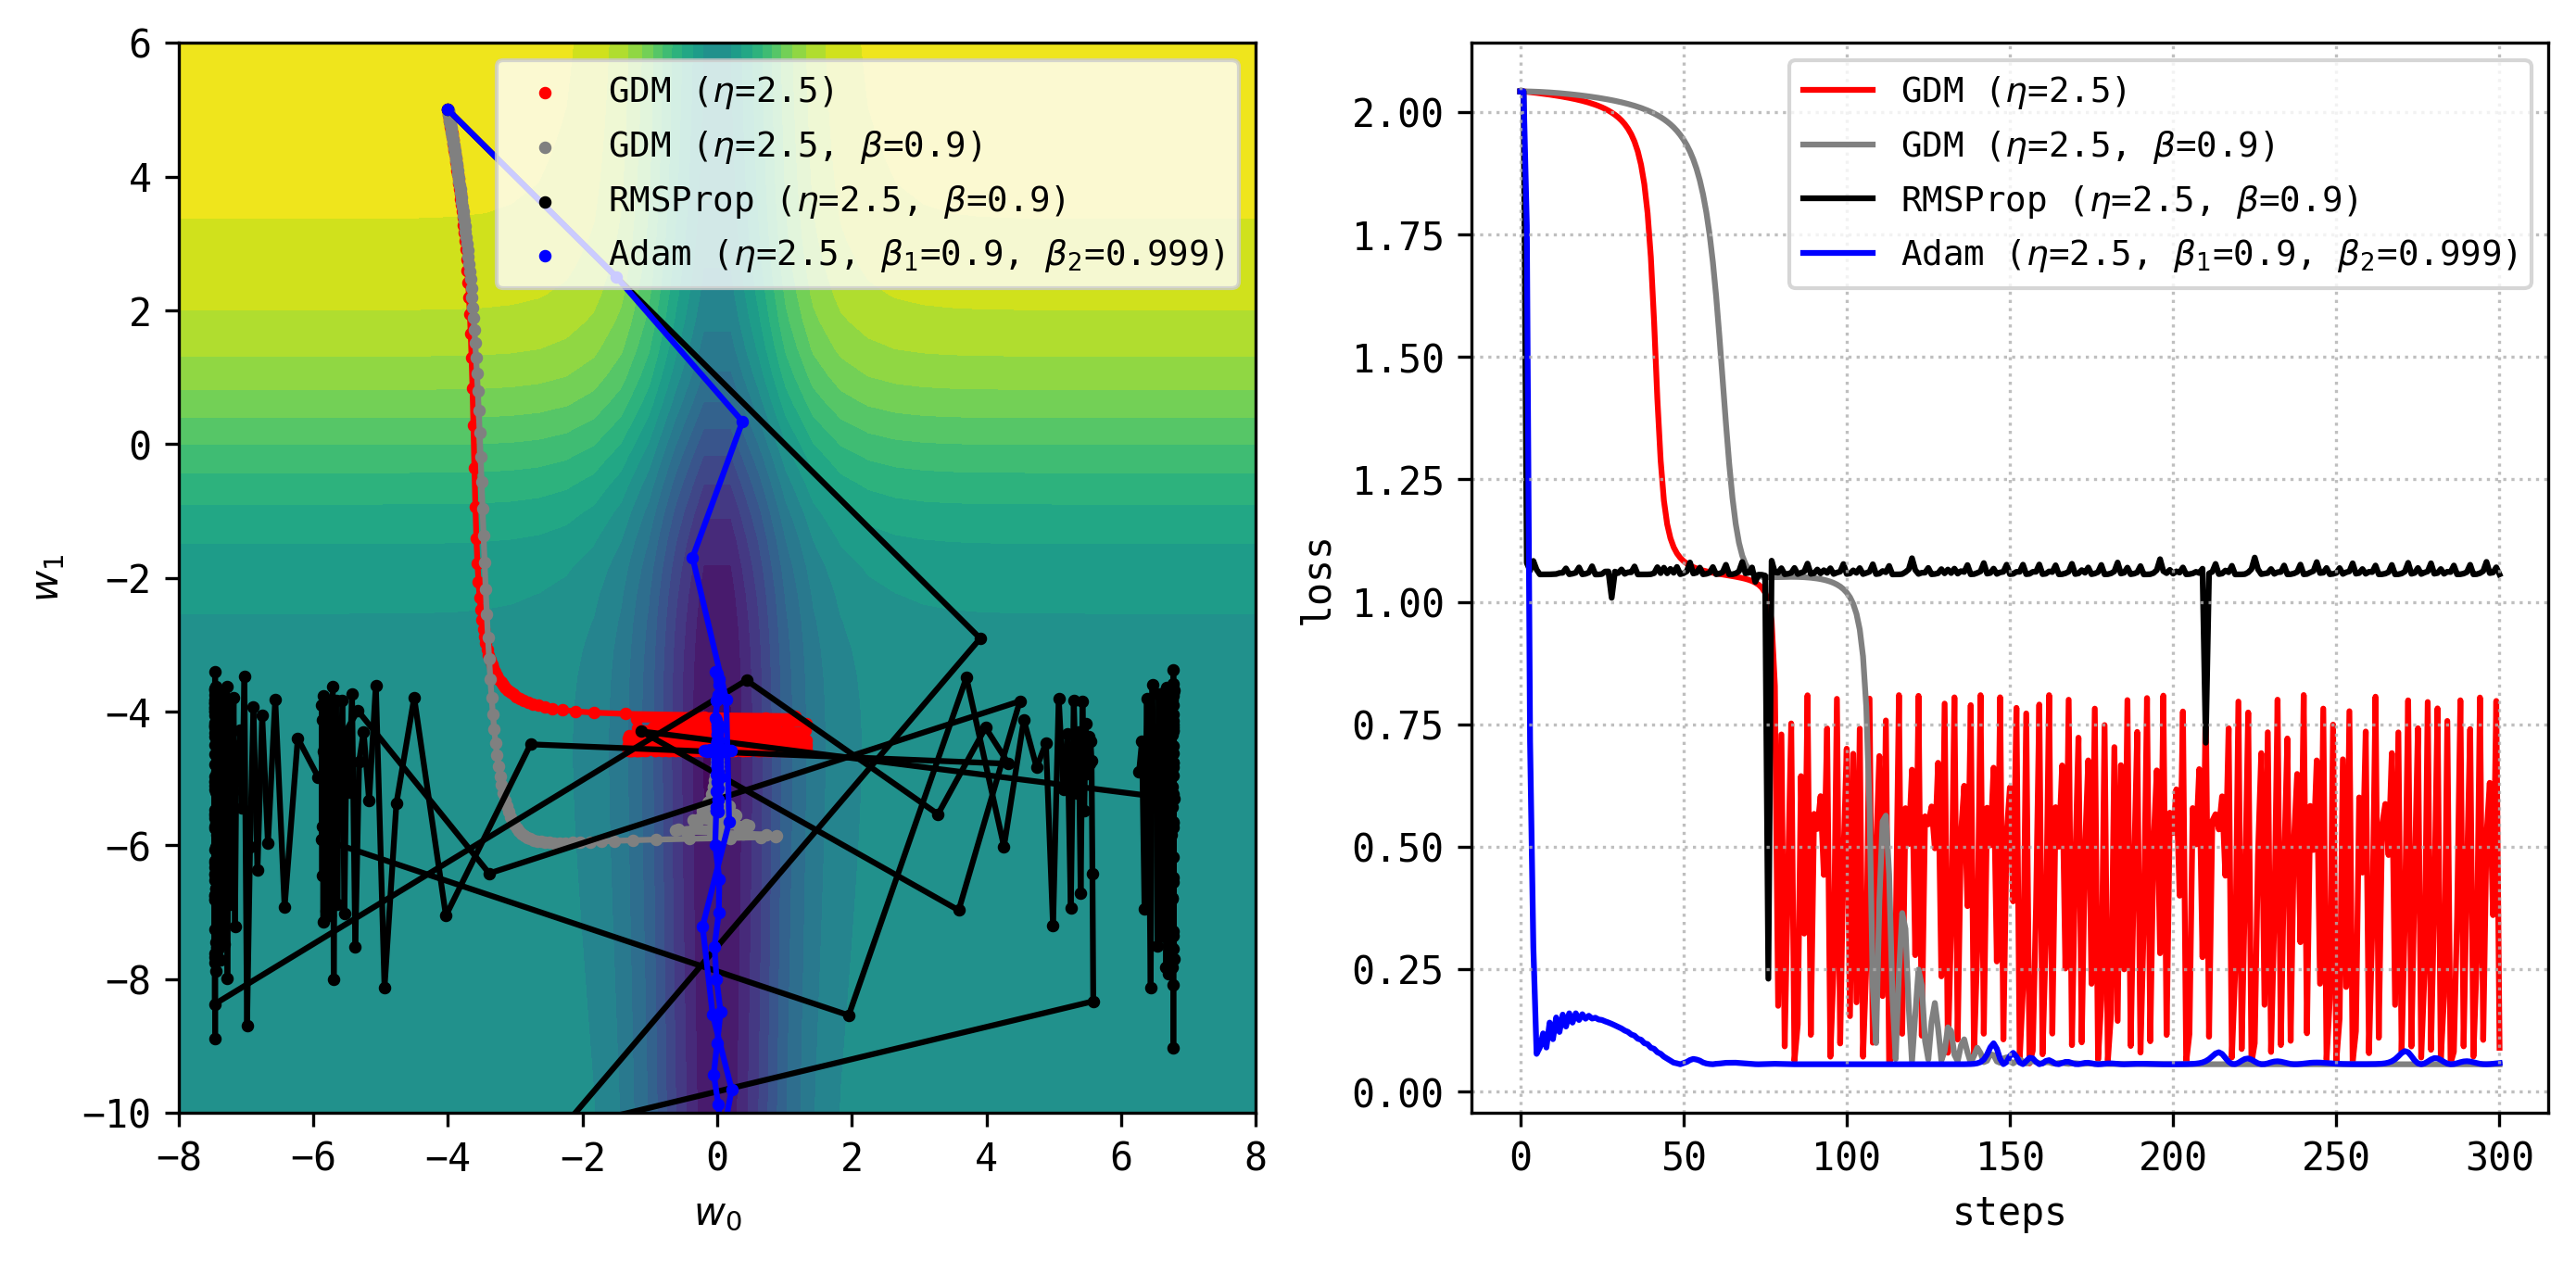

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
plot_gd_steps(ax, optim=GDM,     optim_params={"lr": 2.5},                               w_init=[-4.0, 5.0], label_map=label_map_gdm,     color="red")
plot_gd_steps(ax, optim=GDM,     optim_params={"lr": 2.5, "momentum": 0.9},              w_init=[-4.0, 5.0], label_map=label_map_gdm,     color="grey")
plot_gd_steps(ax, optim=RMSProp, optim_params={"lr": 2.5, "beta": 0.9},                  w_init=[-4.0, 5.0], label_map=label_map_rmsprop, color="black")
plot_gd_steps(ax, optim=Adam,    optim_params={"lr": 2.5, "beta1": 0.9, "beta2": 0.999}, w_init=[-4.0, 5.0], label_map=label_map_adam,    color="blue")

ax[0].set_xlim(-8, 8)
ax[0].set_ylim(-10, 6)
ax[1].set_xlabel("steps")
ax[1].set_ylabel("loss")
ax[1].grid(linestyle="dotted", alpha=0.8)
ax[0].legend(fontsize=9)
ax[1].legend(fontsize=9);

^**Adam has fast convergence. But can be unstable.** Adam like RMSProp converges faster than GD since the update step is not as dependent on the magnitude of the gradient. However, the loss with Adam fluctuates a bit near the end of training. This can be attributed to the oscillations changing orientation, since the step size does not stabilize to zero. This is consistent with folk knowledge that SGD with momentum (discussed below), if tuned well and given enough time to converge, performs better than Adam.

**Remark.** Note that the gradient is coupled with the averaging technique in Adam. If we include regularization or weight decay in the loss, this means weight decay is likewise coupled. This is fixed in **AdamW** {cite:p}`adamw` which adjusts the weight decay term to appear in the gradient update:

$$
\boldsymbol{\boldsymbol{\Theta}}^{t+1} = \boldsymbol{\boldsymbol{\Theta}}^{t} 
- \eta \, 
\left( 
    \frac{\hat{\boldsymbol{\mathsf{m}}}^t}{\sqrt{\hat{\boldsymbol{\mathsf{v}}}^{t}} + \epsilon}
    + \lambda \,\boldsymbol{\Theta}^{t}
\right)
$$

where $\lambda$ is the **weight decay** coefficient. See [AdamW implementation](https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html) in PyTorch.

## Stochastic GD (SGD)

Gradient descent computes gradients for each instance in the training set.
This can be expensive for large datasets.
Note that can take a random subset 
$\mathcal{B} \subset \mathcal{D}$ such that $B = |\mathcal{B}| \ll |\mathcal{D}|$
and still get an unbiased estimate $\mathcal{L}_{\mathcal{B}} \approx \mathcal{L}_\mathcal{D}$
of the empirical loss surface. 
This method is called **Stochastic Gradient Descent** (SGD). This makes sense since $\mathcal{L}_\mathcal{D}$ is also an estimate of the true loss surface that is fixed at each training step.
SGD a lot cheaper to compute compared to batch GD allowing training to progress faster with more updates.
Moreover, SGD has been shown to escape saddle points with some theoretical guarantees {cite:p}`dauphin2014`.
The update rule for SGD is given by:

$$
\boldsymbol{\Theta}^{t+1} = \boldsymbol{\Theta}^t - \eta\; \nabla_{\boldsymbol{\Theta}}\, \mathcal L_{\mathcal{B}}(\boldsymbol{\Theta}^t)
$$

Typically, we take $B = 8, 32, 64, 128, 256.$ Note that SGD is essentially GD above it just replaces the function $f$ at each step with $\mathcal{L}_{\mathcal{B}}.$ Hence, all modifications of GD discussed have the same update rule for SGD and the same results and observations also mostly hold. Although, now we have to reason with noisy approximations $f_t \approx f$ at each step unlike before where it is fixed.

The estimated gradient is *unbiased* in the sense that for fixed $\boldsymbol{\Theta}$, 

$$
\mathbb{E}\left[\frac{1}{B} \sum_{j=1}^{B} \nabla \mathcal{L}_{\mathcal{B}, j}(\boldsymbol{\Theta})\right]=\frac{1}{B} \sum_{j=1}^{B} \frac{1}{N} \sum_{i=1}^N \nabla \mathcal{L}_i(\boldsymbol{\Theta})=\nabla \mathcal{L}(\boldsymbol{\Theta}).
$$

Here the first equality holds because shuffling the dataset at the start of an epoch makes the $j$-th element of the mini-batch $\mathcal{B}$ be any element of the dataset with uniform probability. For the sake of tractability, let's assume that each mini-batch $\mathcal{B}$ is sampled with replacement, so that all samples are independent. This is an approximation of the SGD algorithm used in practice.
Then, the variance of the gradient with uncorrelated mini batches is:

$$
\label{02-variance-sgd}
\mathbb{V}\text{ar}\left(\frac{1}{B} \sum_{j=1}^{B} \nabla \mathcal{L}_{\mathcal{B}, j}\left(\boldsymbol{\Theta}\right)\right)=\frac{1}{B} \,\mathbb{V}\text{ar}\Bigg(\nabla \mathcal{L}_{\mathcal{B}, 1}\left(\boldsymbol{\Theta}\right)\Bigg)
$$

Hence, the variance of SGD updates decrease linearly with increasing batch size $B$. Note that this noise is important for generalization (which intuitively makes sense) as it allows the optimizer to escape [sharp minima](#02-sharp-optim) {cite:p}`sgd_better_than_adam`.#

In [42]:
from functools import partial

def loss(w0, w1, X, y):
    return ((X @ np.array([w0, w1]) - y)**2).mean()

def grad(w, X, y, B=None):
    """Gradient step for the MSE loss function"""
    dw = 2*((X @ w - y).reshape(-1, 1) * X).mean(axis=0)
    return dw / np.linalg.norm(dw)

def sgd(w0, X, y, eta=0.1, steps=10, B=32):
    """Return sequence of weights from GD."""
    w = np.zeros([steps, 2])
    w[0, :] = w0
    for j in range(1, steps):
        batch = torch.randint(0, len(X), size=(B,))
        u = w[j-1, :]
        w[j, :] = u - eta * grad(u, X[batch], y[batch])
    return w


# Generate data
B = 6
n = 1000
X = np.zeros((n, 2))
X[:, 1] = np.random.uniform(low=-1, high=1, size=n)
X[:, 0] = 1
w_min = np.array([-1, 3])
y = (X @ w_min) + 0.05 * np.random.randn(n)  # data: y = -1 + 3x + noise

# Gradient descent
w_init = [-4, -4]
w_step_bgd = sgd(w_init, X, y, eta=0.1, steps=300, B=len(X))
w_step_sgd = sgd(w_init, X, y, eta=0.1, steps=300, B=B)

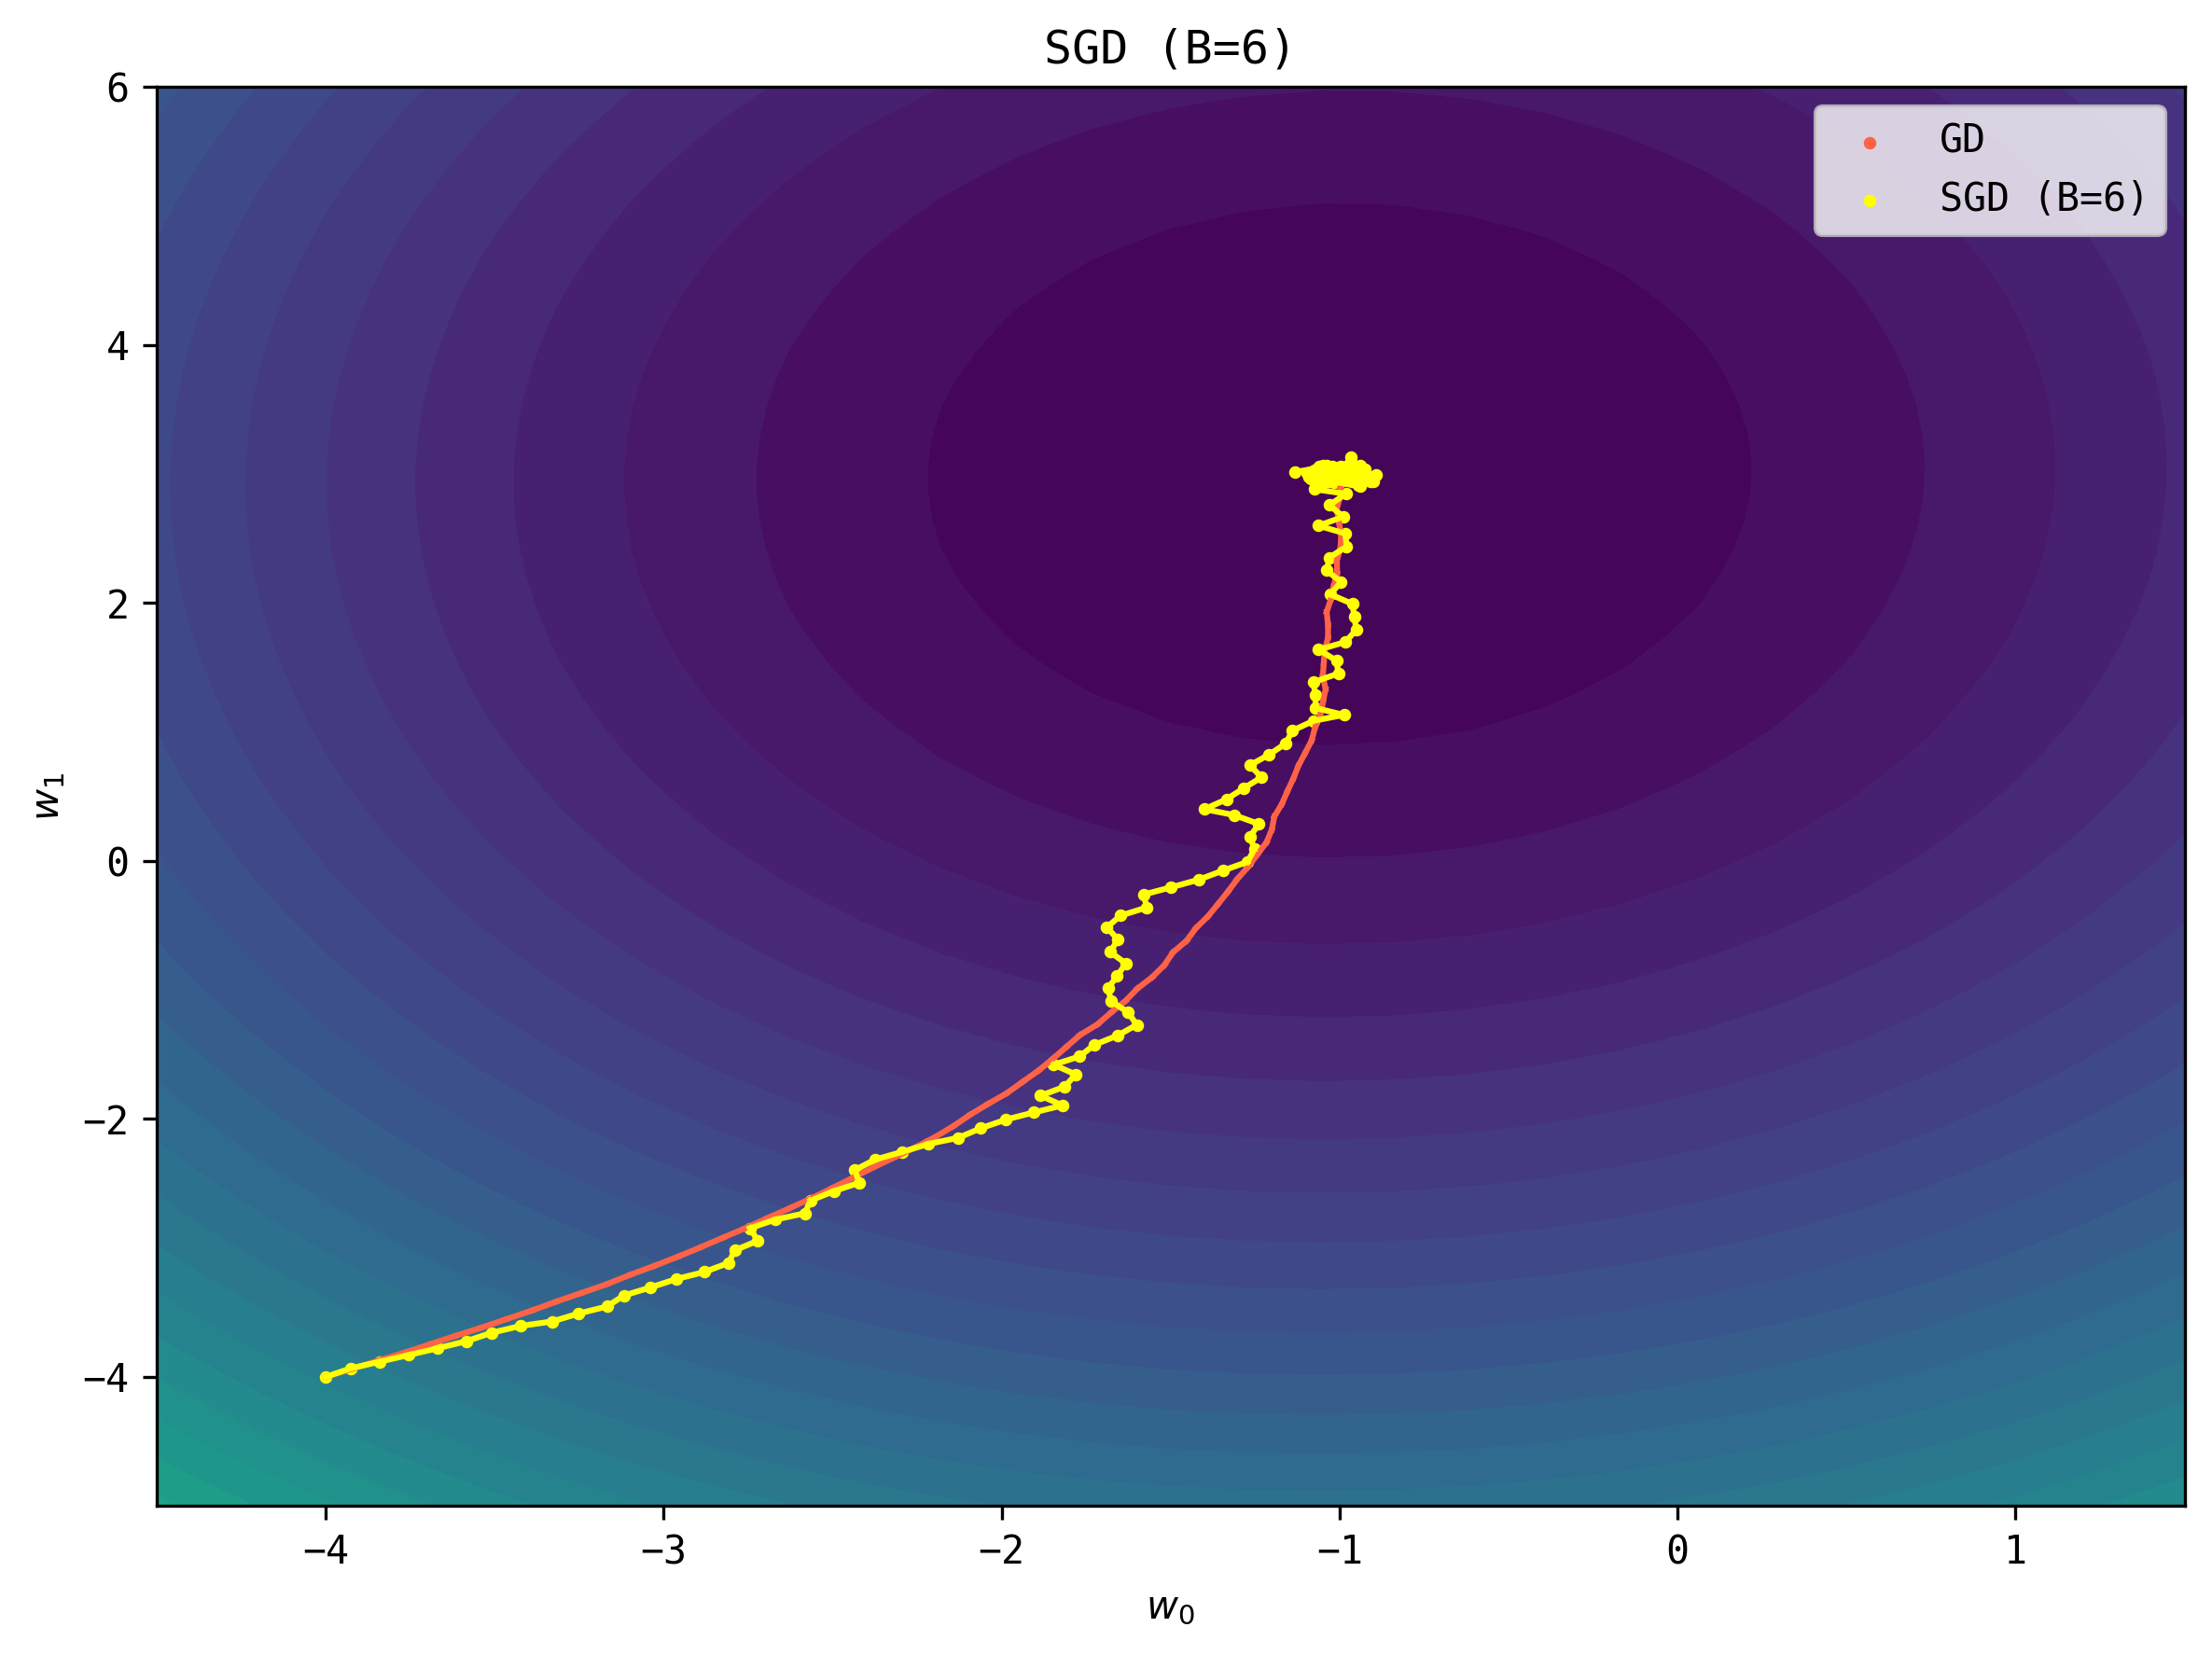

In [43]:
# Create a figure and two subplots
fig = plt.figure(figsize=(8, 6), layout="constrained")
spec = fig.add_gridspec(1, 1)
ax1 = fig.add_subplot(spec[0, 0])

# Call the functions with the respective axes
plot_contourf(ax1, partial(loss, X=X, y=y), w_step_bgd, color="tomato", levels=50, x_min=-6, y_max=6, label="GD")
plot_contourf(ax1, partial(loss, X=X, y=y), w_step_sgd, color="yellow", levels=50, x_min=-6, y_max=6, label=f"SGD (B={B})")
ax1.set_title("GD")
ax1.set_title(f"SGD (B={B})")
fig.tight_layout()
ax1.legend()
ax1.set_ylim(-5, 6)
ax1.set_xlim(-4.5, 1.5);

^**SGD steps are noisy compared to vanilla GD.**
SGD with batch size B=6 and GD with batch size B=1000. The contour plot shows the loss function, and the lines show the trajectory of the weights during training. The updates for $B = 6$ is more erratic than the gradient calculated for the entire training set.
Recall that the gradient is calculated at the current point in the loss surface. The surface is fixed for batch GD. But for SGD, it changes at each step based on the mini-batch sample:

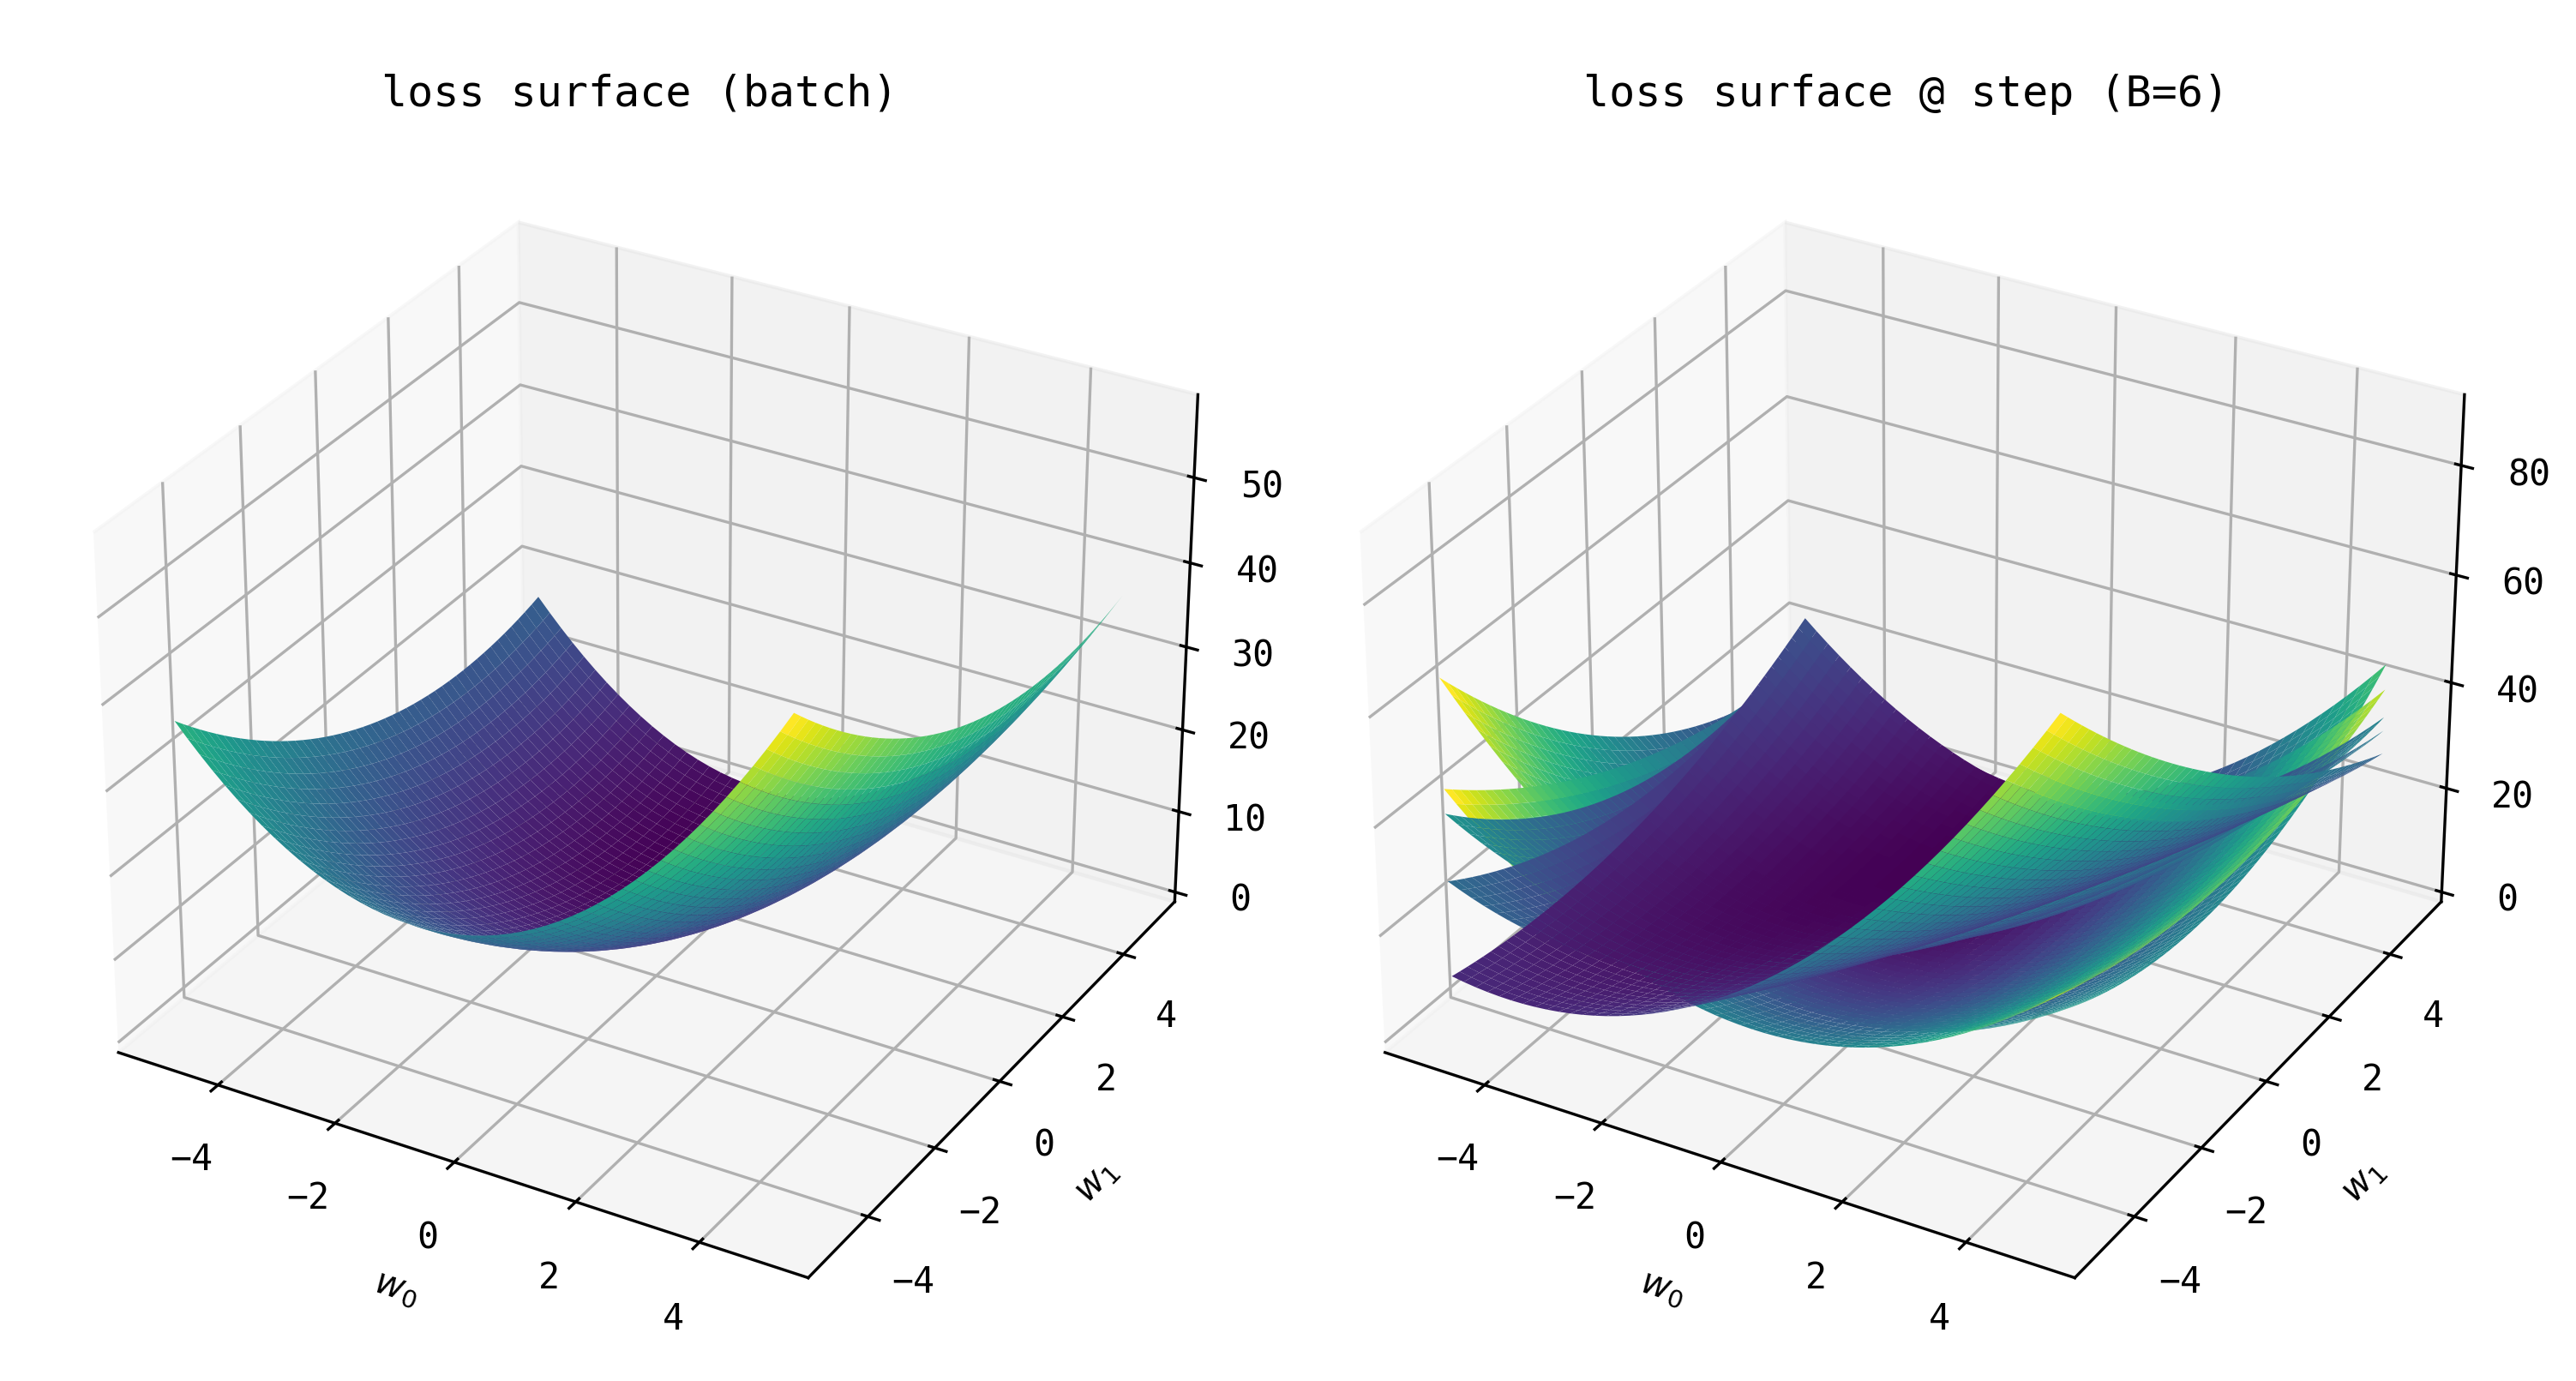

In [44]:
import warnings
warnings.filterwarnings("ignore")

# Create a figure and two subplots
fig = plt.figure(figsize=(10, 6), layout="constrained")
spec = fig.add_gridspec(1, 2)
ax1 = fig.add_subplot(spec[0, 0], projection='3d')
ax2 = fig.add_subplot(spec[0, 1], projection='3d')

# Call the functions with the respective axes
plot_surface(ax1, partial(loss, X=X, y=y), N=50)
for i in range(5):
    batch = torch.randint(0, len(X), size=(B,))
    plot_surface(ax2, f=partial(loss, X=X[batch], y=y[batch]), N=50)

ax1.set_title("\nloss surface (batch)")
ax2.set_title(f"\nloss surface @ step (B={B})")
fig.tight_layout();

^**Loss surface vs loss approximation.** SGD has a different loss approximation at each step.

**Remark.** Sampling from $N \gg 1$ points at each step is expensive. Instead, the dataset is shuffled once at the start of an epoch. Then, the data loader iterates over the slices of size $B$. This is essentially sampling without replacement which turns out to be more [data efficient](https://www.d2l.ai/chapter_optimization/sgd.html#stochastic-gradients-and-finite-samples) (i.e. the model gets to see more varied data). Example with a PyTorch `DataLoader`:

In [45]:
import torch
from torch.utils.data import DataLoader

dataset = torch.arange(10)
train_loader = DataLoader(dataset, batch_size=2, shuffle=True)

print("Epoch 1:")
[print(x) for x in train_loader]
print()
print("Epoch 2:")
[print(x) for x in train_loader];

Epoch 1:
tensor([1, 2])
tensor([0, 7])
tensor([6, 4])
tensor([9, 3])
tensor([5, 8])

Epoch 2:
tensor([1, 2])
tensor([0, 6])
tensor([9, 7])
tensor([3, 4])
tensor([5, 8])


## Hyperparameters

### Batch size

Folk knowledge suggests setting batch sizes as powers of 2: $B = 16, 32, 64, ..., 512.$
Starting with $B = 32$ is recommended for image tasks {cite:p}`batch-size-32`.
Note that we may need to train with large batch sizes depending on the network architecture, the 
nature of the training distribution, or if we have large compute {cite:p}`imagenet1hour`.
Conversely, we may be forced to use small batches due to resource constraints with large models.

**Large batch.** 
Experiments show that increasing batch size with other parameters fixed may result in worse generalization ({numref}`02-large-batch-training`). This can be attributed to batch size decreases gradient noise {eq}`02-variance-sgd` which is important for avoiding overfitting. But less sampling noise means that we can use a larger learning rate, since the loss surface is more stable to different samples. Indeed, {cite:p}`imagenet1hour` used linear scaling of batch size with learning rate (i.e. same factor) allowing training of ResNet-50 on ImageNet in one hour ({numref}`02-imagenet-1-hour`). The graph shows that the simple scaling rule works up to a certain point.


```{figure} ./img/02-large-batch-training.png
---
name: 02-large-batch-training
width: 600px
align: center
---
{cite:p}`sharp_minima_bad` All models are trained in PyTorch using [Adam](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html) 
with default parameters. Large batch training (LB) uses 10% of the dataset while small batch (SB) uses $B = 256$.
The table shows results for models that were not overfitted to the training distribution, with large batch size training having generally worse test performance.
```

**Micro batches.** Using a small batch (e.g. $B \ll 16$, or relative to LR + data efficiency) generally results in slow and unstable convergence since 
the loss surface is poorly approximated at each step. But may be necessary due to memory constraints.
Instead, a larger batch size can be simulated by accumulating gradients from "micro-batches" before performing a weight update. This is called **gradient accumulation**.
Here $\bar{B} \times S = B$, i.e. the actual batch size $\bar{B}$ times the number of gradient accumulation steps $S$ is equal to the ideal batch size $B.$ 

A simple implementation for batches with *fixed number of elements*[^smallbatch] is as follows:

```python
train_loader = DataLoader(dataset, batch_size=B//S, drop_last=True)

for i, (x, y) in enumerate(train_loader):
    outs = model(x)
    loss = loss_fn(outs, y) / S
    loss.backward()

    if (i + 1) % S == 0:
        optim.step()
        optim.zero_grad()
```

**Remark.** Training takes longer by the same factor $S$. But observe that the backward and forward passes for each accumulation step are independent of each other (since the model does not update until the last step). Hence, we can improve training time by using multiple GPUs with [data parallelism](https://docs.nvidia.com/nemo-framework/user-guide/24.09/nemotoolkit/features/parallelisms.html#data-parallelism).

[^smallbatch]: The math trivially checks out whenever $B_a = \bar{B}$ for all $a$:
$\sum_{a=1}^S\sum_{i=1}^{B_a} \frac{1}{S \times B_a} \nabla \mathcal{L}_{ai}.$
But with output sequences, 
$\frac{1}{S}\sum_{a=1}^S \frac{1}{ N_a} \sum_{i=1}^{B_a} \sum_{t = 1}^{T_{ai}} \nabla \mathcal{L}_{ait}$
such that $N_a = \sum_{i=1}^{B_a} T_{ai}$ is the sum of sequence lengths which generally varies (e.g. ignoring padding tokens).
This basically separates the entire fraction into partial fractions. <br><br>Recall that cross-entropy for a batch of sequences is calculated by accumulating all instance losses regardless of which sequence it belongs in. Hence, the invariance for any $S = 1, 2, \ldots$ is violated. Invariance is satisfied with: $\frac{1}{N} \sum_{a=1}^S \sum_{i=1}^{B_a} \sum_{t = 1}^{T_{ai}} \nabla \mathcal{L}_{ait}$ where $N = \sum_{a=1}^S \sum_{i=1}^{B_a} T_{ai}.$ That is, normalization is applied only after adding all the terms. Finally, this example demonstrates how silent calculation errors can cause significant differences in training outcomes and cumulative training cost in deep learning. See this [blog post](https://unsloth.ai/blog/gradient).

**Remark.** GPU is underutilized when $B$ is small, and we can get OOM when $B$ is large.
In general, hardware constraints should be considered in parallel with theory.
GPU can idle if there is lots of CPU processing on a large batch, for example. One can set 
`pin_device=True` can be set in the data loader to speed up data transfers to 
the GPU by leveraging [page locked memory](https://leimao.github.io/blog/Page-Locked-Host-Memory-Data-Transfer/). 
Similar tricks
({numref}`02-gpu-tricks`) have to be tested empirically to see whether it works on your
use-case. These are hard to figure out based on first principles. 

```{figure} ./img/02-gpu-tricks.png
---
name: 02-gpu-tricks
width: 600px
align: center
---
A [tweet](https://twitter.com/karpathy/status/1299921324333170689?s=20) by Andrej Karpathy
on tricks to optimize Pytorch code. The linked [video](https://www.youtube.com/watch?v=9mS1fIYj1So).
```


:::{dropdown} ⓘ &nbsp; Batches of sequences of varying lengths
To maintain invariance with $S$, we accumulate all contributions in a batch before normalizing 
since the number of elements summed over in calculating the cross-entropy varies for each micro-batch:

```python
# -100 is the ignore index for F.cross_entropy
IGNORE_IDX = -100
train_loader = DataLoader(dataset, batch_size=B//S, drop_last=True)

m = 0
for i, (x, y) in enumerate(train_loader):
    outs = model(x)     # (B, C, T)
    loss = F.cross_entropy(outs, y, reduction="sum")
    loss.backward()
    m += (y != IGNORE_IDX).int().flatten().sum()

    if (i + 1) % S == 0:
        for p in model.parameters():
            p.grad /= m
        optim.step()
        optim.zero_grad()
        m = 0
```
:::

In [47]:
# TEST: correctness of gradient accumulation w/ seqs of varying length

import torch
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim.optimizer
from torch.utils.data import TensorDataset, DataLoader

N = 7331
T = 20
C = 10

def reseed():
    random.seed(0)
    np.random.seed(0)
    torch.manual_seed(0)

def get_model():
    reseed()
    return torch.nn.Sequential(
        nn.Linear(4, 5),
        nn.ReLU(),
        nn.Linear(5, 10)
    )

def get_dataloader(B, masked=False):
    reseed()
    mask = torch.randint(0, 2, size=(N, T))
    x = torch.randn(size=(N, T, 4))
    y = torch.randint(0, C, size=(N, T))
    dataset = TensorDataset(
        x,
        y * mask + 100 * (mask - 1) if masked else y
    )
    return DataLoader(dataset, batch_size=B, drop_last=True)


for S in [1, 2, 4, 8]:
    reseed()
    B = 32
    model = get_model()
    optim = torch.optim.SGD(model.parameters(), lr=0.01)
    train_loader = get_dataloader(B // S, masked=True)
    
    m = 0
    for i, (x, y) in enumerate(train_loader):
        outs = model(x).permute(0, 2, 1)
        loss = F.cross_entropy(outs, y, reduction="sum")
        loss.backward()
        m += (y != -100).int().flatten().sum()

        if (i + 1) % S == 0:
            for p in model.parameters():
                p.grad /= m
            optim.step()
            optim.zero_grad()
            m = 0

    xt = torch.randn(size=(256, T, 4))
    yt = torch.randint(0, 9, size=(256, T))
    print(F.cross_entropy(model(xt).permute(0, 2, 1), yt).item())

2.3523926734924316
2.3523926734924316
2.3523926734924316
2.3523926734924316


### Learning rate

Finding an optimal learning rate (LR) is essential for test performance and 
faster convergence, even for adaptive optimizers like Adam. In practice, we first determine the batch size based on hardware constraints such as GPU/CPU efficiency, memory, and data transfer latency. Then, we tune the learning rate by (1) selecting a **base LR** and (2) an LR decay **policy** or **schedule**. If we find a good base LR, and want to change the batch size, we have to scale the LR linearly with the same factor {cite:p}`imagenet1hour` {cite:p}`learning-rate-function-of-batch-size`. 
This means smaller LR for smaller batches, and vice-versa ({numref}`02-imagenet-1-hour`).

```{figure} ./img/02-imagenet-1-hour.png
---
name: 02-imagenet-1-hour
width: 500px
align: center
---
From {cite:p}`imagenet1hour`.  For all experiments 
$B \leftarrow aB$ and $\eta \leftarrow a\eta$
sizes are set. Note that a simple warmup phase for the first few epochs of
training until the learning rate stabilizes to $\eta$ since 
early steps are away from any minima, hence can be unstable. 
All other hyper-parameters are kept fixed. Using this
simple approach, accuracy of our models is invariant to minibatch
size (up to an 8k minibatch size). The authors were able to train
ResNet-50 on ImageNet in 1 hour using 256 GPUs with 90% scaling efficiency relative to the baseline of using 8 GPUs.
```

**LR finder.** Below is a parameter-free approach to finding a base learning rate.
The idea is to select a maximally large base LR without the loss diverging
at the starting steps of training.
This allows the optimizer to initially explore the surface with less risk of 
getting stuck in plateaus, at the same time avoiding divergence.

In [48]:
num_steps = 1000
lre_min = -2.0
lre_max =  0.6
lre = torch.linspace(lre_min, lre_max, num_steps)
lrs = 10 ** lre
w = nn.Parameter(torch.FloatTensor([-4.0, -4.0]), requires_grad=True)
optim = Adam([w], lr=lrs[0])

losses = []
for k in range(num_steps):
    optim.lr = lrs[k]   # (!) change LR at each step
    optim.zero_grad()
    loss = pathological_loss(w[0], w[1])
    loss.backward()
    optim.step()
    losses.append(loss.item())

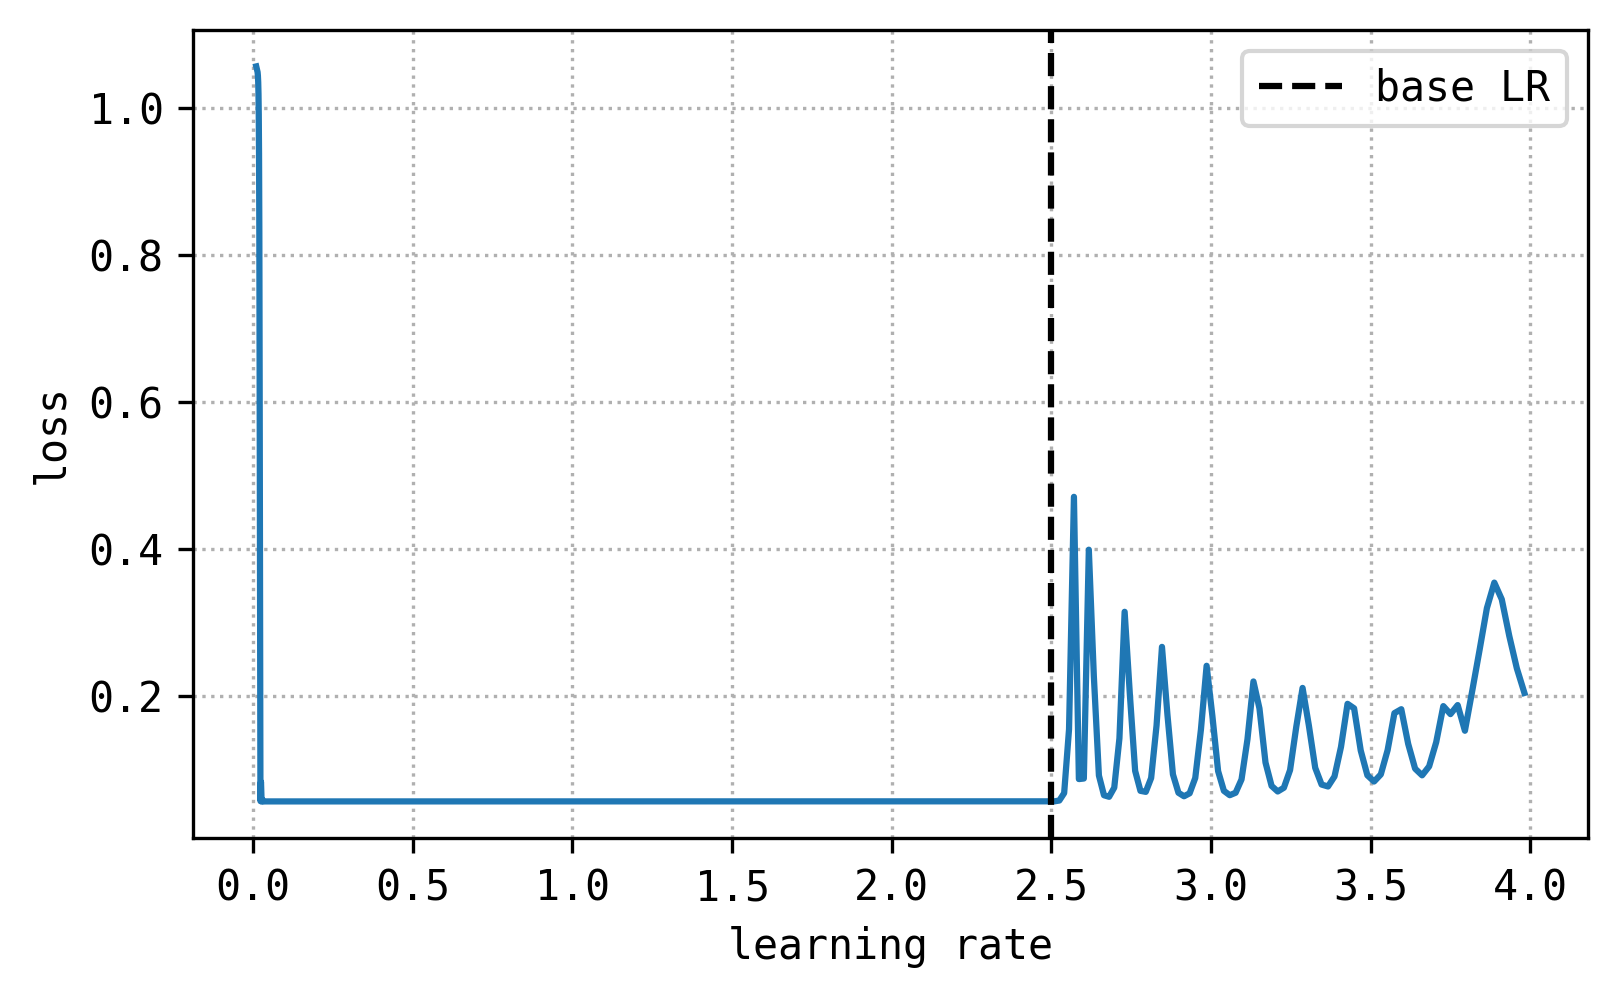

In [49]:
plt.figure(figsize=(6, 3.5))
plt.plot(lrs.detach(), losses)
plt.xlabel("learning rate")
plt.ylabel("loss")
plt.grid(linestyle='dotted')
plt.axvline(2.5, color='k', linestyle='dashed', label='base LR')
plt.legend();

^**LR finder applied on the pathological loss.** Notice that sampling is biased towards small learning rates. This makes sense since large learning rates tend to diverge. The graph is not representative for practical problems since the network is small and the loss surface is relatively simple. But following the algorithm, `lr=2.0` may be chosen as the base learning rate.

**LR scheduling.** Learning rate has to be decayed in some way help with convergence. 
Recall that this happens automatically using adaptive methods, but having a 
policy that does not depend on the current gradient values still helps, especially given a predetermined computational budget.
The ff. adds a simple schedule to the original training scrip. Repeating the same experiment above for RMSProp and GD which had issues with oscillation:

In [50]:
def train_curve(
    optim: OptimizerBase, 
    optim_params: dict, 
    w_init=[5.0, 5.0], 
    loss_fn=pathological_loss, 
    num_steps=100
):
    """Return trajectory of optimizer through loss surface from init point."""

    w_init = torch.tensor(w_init).float()
    w = nn.Parameter(w_init, requires_grad=True)
    optim = optim([w], **optim_params)
    points = [torch.tensor([w[0], w[1], loss_fn(w[0], w[1])])]
    
    for step in range(num_steps):
        optim.zero_grad()
        loss = loss_fn(w[0], w[1])
        loss.backward()
        optim.step()

        # logging
        with torch.no_grad():
            z = loss.unsqueeze(dim=0)
            points.append(torch.cat([w.data, z]))

        # LR schedule <<<<
        if step % 70 == 0:
            optim.lr *= 0.5

    return torch.stack(points, dim=0).numpy()

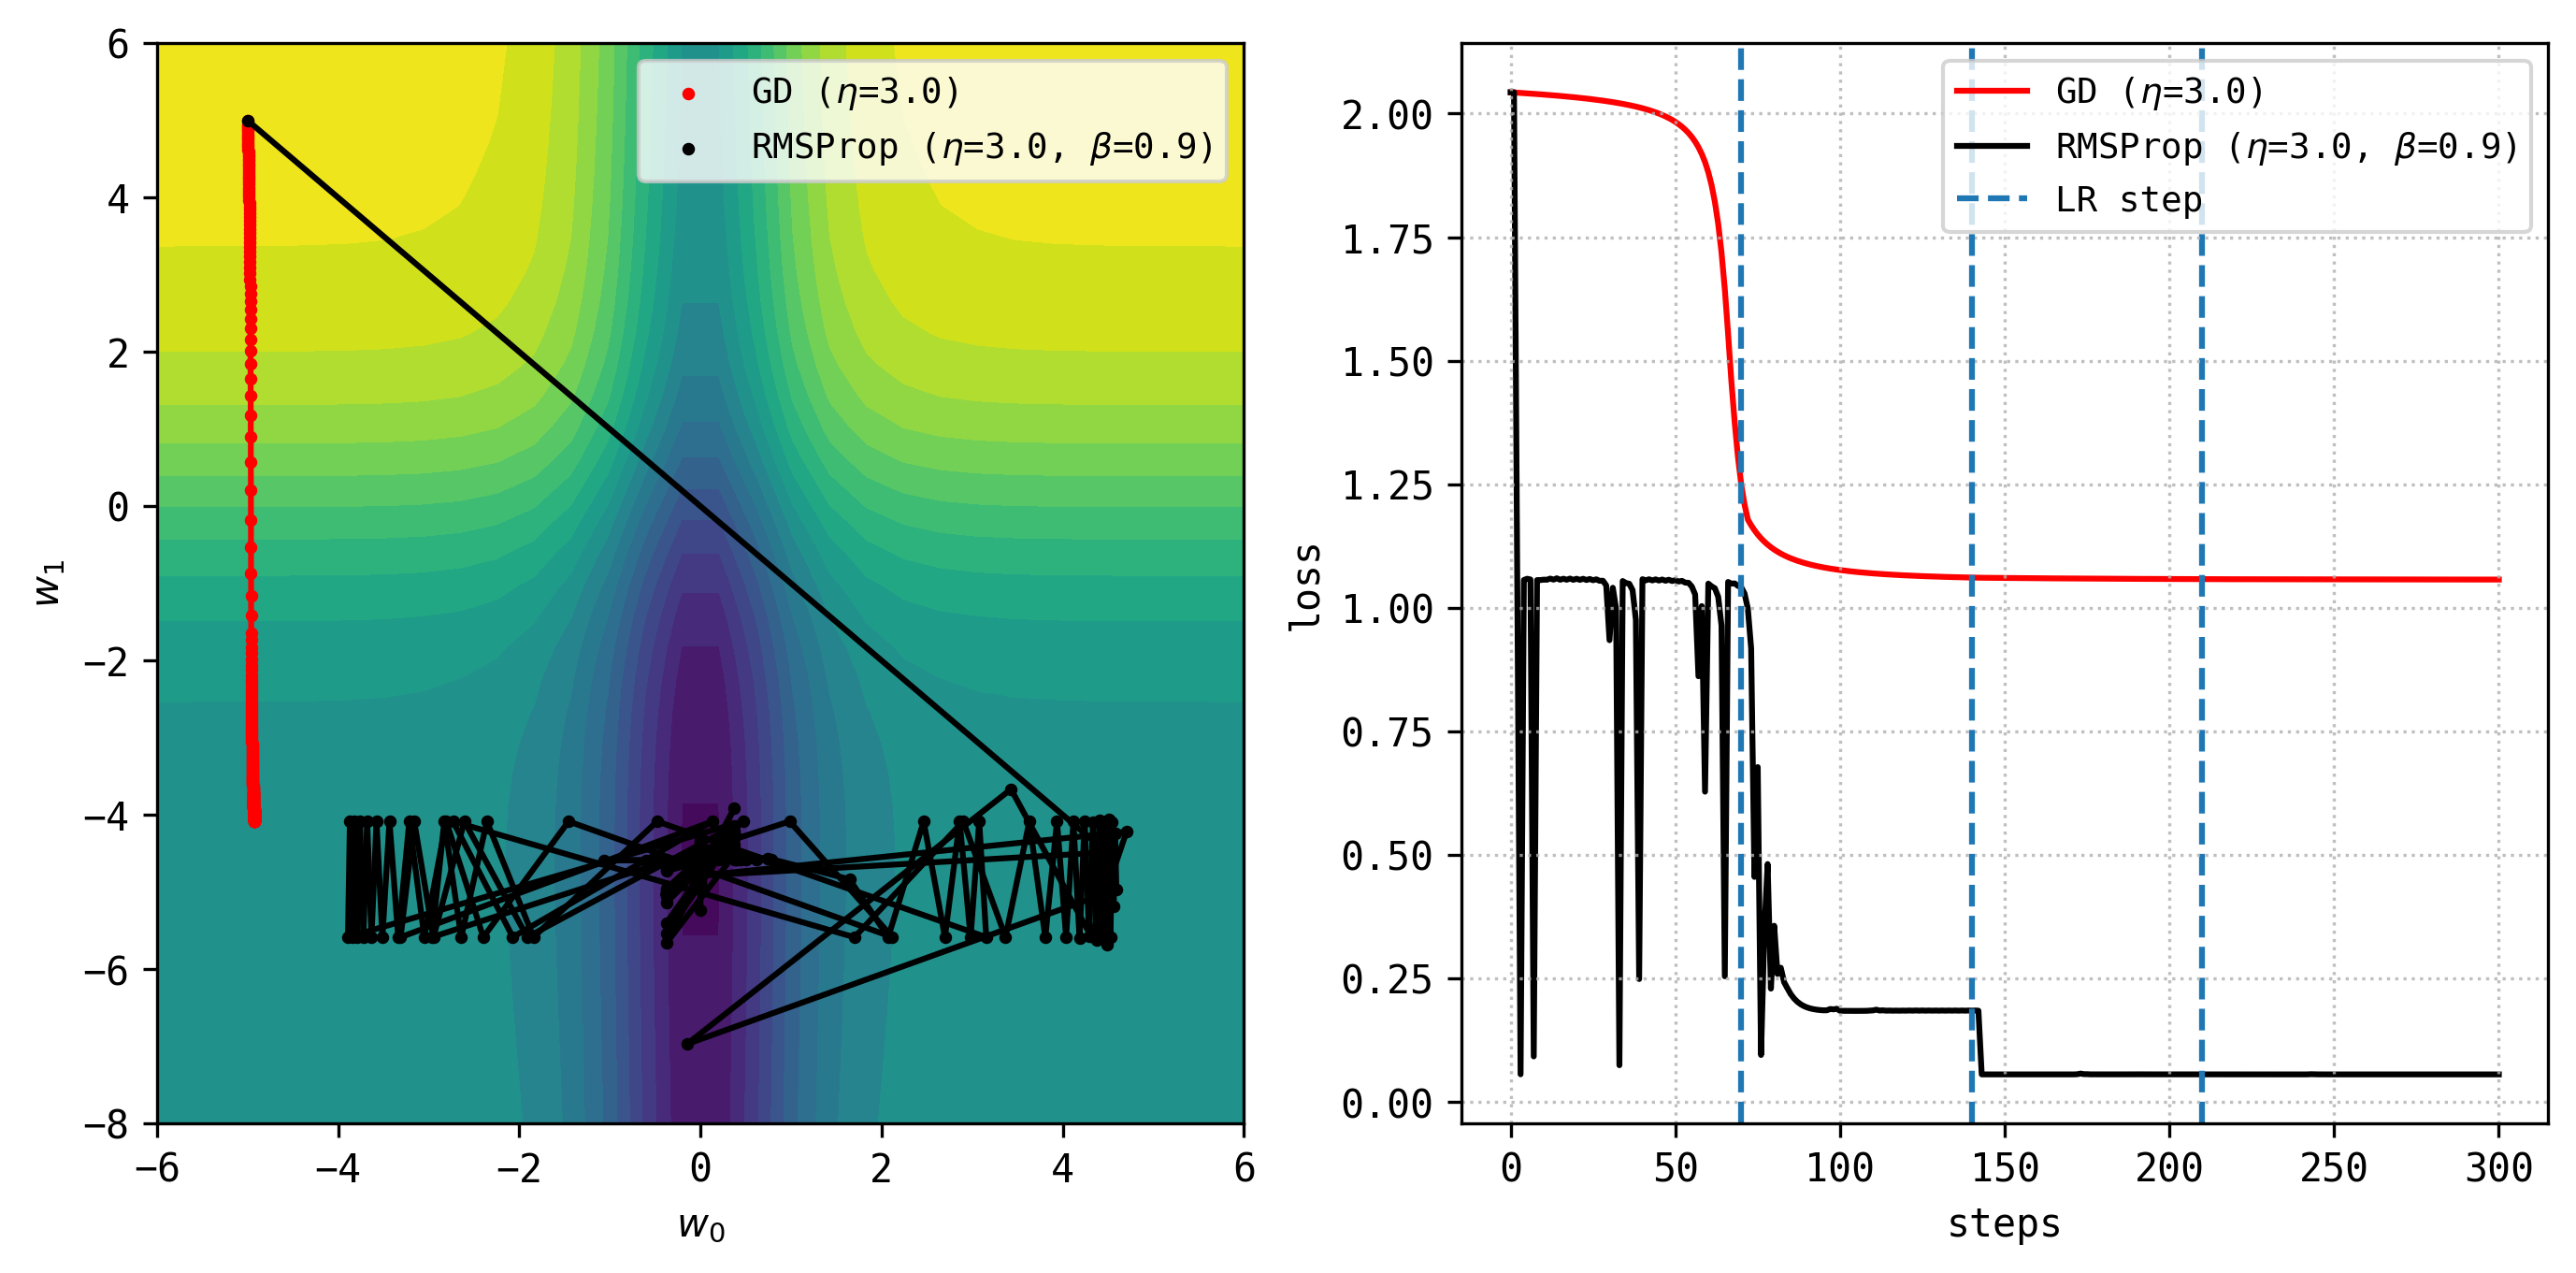

In [51]:
label_map_gdm = {"lr": r"$\eta$", "momentum": r"$\beta$"}
label_map_rmsprop = {"lr": r"$\eta$", "beta": r"$\beta$"}
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
plot_gd_steps(ax, optim=GD,      optim_params={"lr": 3.0},              w_init=[-5.0, 5.0], label_map=label_map_gdm,     color="red")
plot_gd_steps(ax, optim=RMSProp, optim_params={"lr": 3.0, "beta": 0.9}, w_init=[-5.0, 5.0], label_map=label_map_rmsprop, color="black")

ax[0].set_xlim(-6, 6)
ax[0].set_ylim(-8, 6)
ax[1].set_xlabel("steps")
ax[1].set_ylabel("loss")
ax[1].axvline(70, linestyle='dashed')
ax[1].axvline(140, linestyle='dashed')
ax[1].axvline(210, linestyle='dashed', label='LR step', zorder=1)
ax[1].grid(linestyle="dotted", alpha=0.8)
ax[0].legend(fontsize=9)
ax[1].legend(fontsize=9);

^**Learning rate schedule with SGDM and RMSProp.** The dashed lines indicate the learning rate schedule steps. Notice rapid drop for RMSProp in loss each time learning rate is updated.

Learning rate decay decreases GD oscillation drastically. The schedule $\boldsymbol{\boldsymbol{\Theta}}^{t+1} = \boldsymbol{\boldsymbol{\Theta}}^{t} - \eta \frac{1}{\alpha^t} \, \boldsymbol{\mathsf{m}}^{t}$ where $\alpha^t = 2^{\lfloor t / 100 \rfloor}$ is known as **step LR decay**. Note that this augments the second-moment for RMSProp which already auto-tunes the learning rate. Here we are able to start with a large learning rate allowing the optimizer to escape the first plateau earlier than before. Note that decay only decreases learning rate which can cause slow convergence. But there are schedules that implement increasing LR such as **warm restarts** ({numref}`02-sgd-warm-restarts`).

**Remark.** For more examples of learning rate decay schedules [see here](https://d2l.ai/chapter_optimization/lr-scheduler.html#schedulers)  (e.g. **warmup** which initially gradually increases learning rate since SGD at initialization can be unstable with large LR). Also see [PyTorch docs](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate) on LR schedulers available in the library. For example, the schedule **reduce LR on plateau** that reduces the learning rate once a metric has stopped improving is implemented in PyTorch as `ReduceLROnPlateau` in the `torch.optim.lr_scheduler` library.

```python
# Example: PyTorch code for chaining LR schedulers
optim = SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler1 = ExponentialLR(optim, gamma=0.9)
scheduler2 = MultiStepLR(optim, milestones=[30,80], gamma=0.1)

for epoch in range(10):
    for x, y in dataset:
        optim.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optim.step()
    
    # LR step called after optimizer update! ⚠⚠⚠
    scheduler1.step()
    scheduler2.step()
```

<br>

```{figure} ./img/02-sgd-warm-restarts.png
---
name: 02-sgd-warm-restarts
width: 60%
align: center
---
**More complex schedules exist: combining increasing and decreasing LR.**
Cosine annealing starts with a large learning rate that is relatively rapidly decreased to a minimum value before being increased rapidly again. This resetting acts like a simulated restart of the model training and the re-use of good weights as the starting point of the restart is referred to as a "warm restart" in contrast to a "cold restart" at initialization. Source: {cite:p}`sgd-warm-restarts`
```

```{figure} ./img/02-snapshot-ensembles.png
---
name: 02-snapshot-ensembles
width: 80%
align: center
---
**Effect of cyclical learning rates.** Each model checkpoint for each LR warm restart (which often correspond to a minimum) can be used to create an ensemble model. **Source:** {cite:p}`snapshot-ensembles`
```

### SGD + Momentum

Good starting values for SGD momentum are $\beta = 0.9$ or $0.99$. Adam is easier to use out of the box where we like to keep the default parameters. If we have resources, and we want to push test performance, we can
tune SGD which is known to generalize better than Adam with more epochs. See {cite:p}`sgd_better_than_adam` which claims that Adam is more stable than SGD at [sharp minima](#02-sharp-optim) due to adaptive step sizes smoothing out gradient noise, leading to lighter-tailed noise distribution.

**Pro tip:** SGD might be preferable despite slower convergence. But if fast training is critical (e.g., in large-scale RL), Adam with tricks like late-stage SGD switching for better final performance, can be a good tradeoff.


```{figure} ./img/02-sharp-optim.png
---
name: 02-sharp-optim
width: 80%
align: center
---
**A conceptual sketch of flat and sharp minima.** The Y-axis indicates value of the loss
function and the X-axis the variables. The dashed curve is a result of perturbation with different training samples in the same distribution. Hence, sharp minima tend to generalize worse than flat ones. **Source:** {cite:p}`sharp_minima_bad`
```

**Remark.** In principle, optimization hyperparameters affect training, not generalization. But the situation is more complex with SGD, where stochasticity
contributes to regularization. See {numref}`02-large-batch-training` where choice of $B$ influences
generalization. Recall also that for batch GD (i.e. $B = N$ in SGD), consecutive gradients approaching a minimum 
roughly have the same direction. 
This should not happen with SGD with $B \ll N$ in the learning regime as different samples 
will capture different aspects of the loss surface.
Otherwise, the network is starting to overfit. So in practice, optimization hyperparameters 
are tuned on the validation set as well.

---